# Run first

In [29]:
import yt 
import numpy as np

def _gamma(field, data):
    u1 = data[('gas', 'four_velocity_r')]
    u2 = data[('gas', 'four_velocity_theta')]
    u3 = data[('gas', 'four_velocity_z')]
    c = data.ds.quan(1.0, 'code_velocity')
    return (1 + (u1/c)**2 + (u2/c)**2 + (u3/c)**2)**0.5


yt.add_field(('gas', 'lorentz_gamma'), function=_gamma, units="", sampling_type = "cell", dimensions = yt.units.dimensionless)
# Cartesian components of the SPATIAL FOUR-VELOCITY, from the native cylindrical fields.
# Athena++ SR stores u^i = gamma*v^i in the primitive velocity slots, NOT the 3-velocity
# (adiabatic_hydro_sr.cpp: prim(IVX) = gamma*v1).  So:
# ('athena_pp', 'vel1') = u_R,  ('athena_pp', 'vel2') = u_phi
# ('index', 'theta')    = azimuthal angle phi of each cell
# These are physical (orthonormal) components, so a plain rotation is correct:
# u_x = u_R*cos(phi) - u_phi*sin(phi)
# u_y = u_R*sin(phi) + u_phi*cos(phi)
# Recover a 3-velocity with v = u / sqrt(1 + |u|^2) where |u|^2 sums ALL three components.
def _u_cyl_x(field, data):
    phi  = data[('index', 'theta')]
    ur   = data[('athena_pp', 'vel1')]
    uphi = data[('athena_pp', 'vel2')]
    return ur * np.cos(phi) - uphi * np.sin(phi)

def _u_cyl_y(field, data):
    phi  = data[('index', 'theta')]
    ur   = data[('athena_pp', 'vel1')]
    uphi = data[('athena_pp', 'vel2')]
    return ur * np.sin(phi) + uphi * np.cos(phi)

yt.add_field(('gas', 'u_cyl_x'), function=_u_cyl_x,
             units='code_velocity', sampling_type='cell', force_override=True)
yt.add_field(('gas', 'u_cyl_y'), function=_u_cyl_y,
             units='code_velocity', sampling_type='cell', force_override=True)

In [30]:
def _enthalpy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return 1 + 4*P/(rho*c**2)


yt.add_field(('gas', 'enthalpy'), function=_enthalpy, units="", sampling_type="cell", dimensions=yt.units.dimensionless)

def _entropy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return P/rho**(4/3)

yt.add_field(('gas', 'entropy'), function=_entropy, units="code_length**3/(code_mass**(1/3)*code_time**2)", sampling_type="cell")

# ds/dt

yt : [WARNING  ] 2026-09-23 12:24:21,935 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:24:21,935 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:24:21,935 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:24:21,935 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-09-23 12:24:21,955 Parameters: current_time              = 4.970019721026554
yt : [INFO     ] 2026-09-23 12:24:21,955 Parameters: domain_dimensions         = [2400 1200    1]
yt : [INFO     ] 2026-09-23 12:24:21,955 Parameters: domain_left_edge          = [0.01 0.   0.  ]
yt : [INFO     ] 2026-09-23 12:24:21,955 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-09-23 12:24:21,956 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-09-23 12:24:22,027 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:24:22,027 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:24:22,027 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:24:22,027 Assuming 1.0 = 1.0 K
yt : [IN


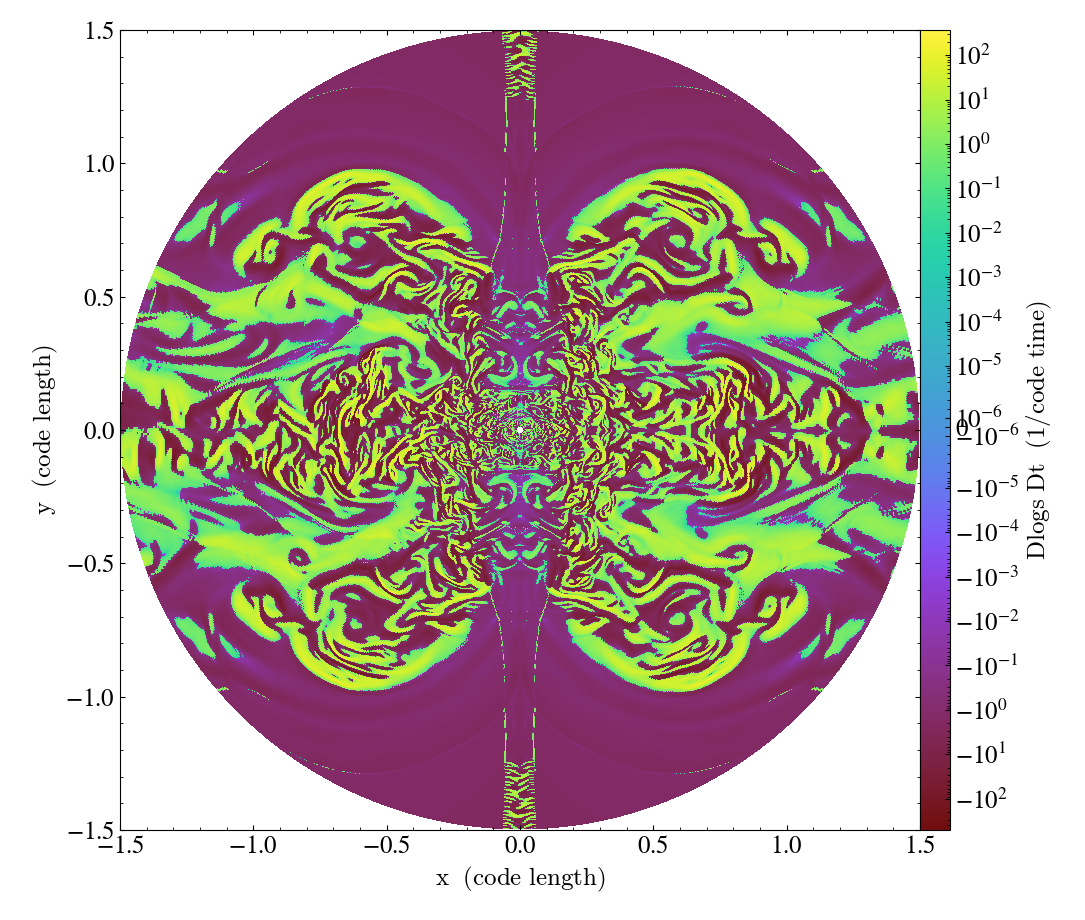

In [31]:


ds1 = yt.load('/scratch/aripoll/athena_out/outputs/jb_exp.out1.04970.athdf')
ds2 = yt.load('/scratch/aripoll/athena_out/outputs/jb_exp.out1.04971.athdf')
dt = float(ds2.current_time - ds1.current_time)
dims = ds1.domain_dimensions
le, re = ds1.domain_left_edge.v, ds1.domain_right_edge.v

cg1 = ds1.covering_grid(0, left_edge=ds1.domain_left_edge, dims=dims)
cg2 = ds2.covering_grid(0, left_edge=ds2.domain_left_edge, dims=dims)

dlogS_dt_arr = (np.log(cg2[('gas', 'entropy')].v) - np.log(cg1[('gas', 'entropy')].v)) / dt

def _dlogS_dt(field, data):
    pts = data.fcoords.v
    i0 = np.clip(((pts[:, 0] - le[0]) / (re[0] - le[0]) * dims[0]).astype(int), 0, dims[0]-1)
    i1 = np.clip(((pts[:, 1] - le[1]) / (re[1] - le[1]) * dims[1]).astype(int), 0, dims[1]-1)
    return data.ds.arr(dlogS_dt_arr[i0, i1, 0], '1/code_time')


ds1.add_field(('gas', 'dlogS_dt'), function=_dlogS_dt,
              units='1/code_time', sampling_type='cell', force_override=True)
p = yt.SlicePlot(ds1, 'z', ('gas', 'dlogS_dt'))
p.show()


In [32]:
#%% Shock tracker — appends to the existing CSV
import yt
import numpy as np
import pandas as pd

THRESHOLD = 1e3
OUT_CSV   = '/scratch/aripoll/athena_out/outputs/dt_shock_track_exp.csv'



ts   = yt.load('/scratch/aripoll/athena_out/outputs/jb_exp.out1.*.athdf')
dims = ts[0].domain_dimensions  # (nr, nphi, 1)

# Build coordinate arrays once — fixed grid, same for every timestep
ds0     = ts[0]
le, re  = ds0.domain_left_edge.v, ds0.domain_right_edge.v
nr, nphi = int(dims[0]), int(dims[1])

r_arr       = le[0] + (np.arange(nr)   + 0.5) * (re[0] - le[0]) / nr
phi_arr     = le[1] + (np.arange(nphi) + 0.5) * (re[1] - le[1]) / nphi
phi_deg_arr = np.degrees(phi_arr)

S_prev = None
t_prev = None
total_rows = 0

for ds in ts:
    cg = ds.covering_grid(0, left_edge=ds.domain_left_edge, dims=dims)
    S  = cg[('gas', 'entropy')].v          # (nr, nphi, 1)
    t  = float(ds.current_time)

    if S_prev is not None:
        dt       = t - t_prev
        dlogS    = (np.log(S) - np.log(S_prev))[:, :, 0] / dt  # (nr, nphi)
        ir, iphi = np.where(dlogS > THRESHOLD)
        if len(ir):
            pd.DataFrame({'time': t_prev,
                          'r': r_arr[ir],
                          'phi_deg': phi_deg_arr[iphi],
                          'dlogS_dt': dlogS[ir, iphi]}
                         ).to_csv(OUT_CSV, mode='a', header=False, index=False)
            total_rows += len(ir)

    S_prev = S
    t_prev = t

done = pd.read_csv(OUT_CSV, usecols=['time'])
print(f'added {total_rows:,} rows from frames {START}:{STOP}')
print(f'file now {len(done):,} rows, t={done.time.min():.2f}-{done.time.max():.2f}')

yt : [WARNING  ] 2026-09-23 12:24:25,956 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:24:25,957 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:24:25,957 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:24:25,957 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-09-23 12:24:25,977 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-23 12:24:25,977 Parameters: domain_dimensions         = [2400 1200    1]
yt : [INFO     ] 2026-09-23 12:24:25,977 Parameters: domain_left_edge          = [0.01 0.   0.  ]
yt : [INFO     ] 2026-09-23 12:24:25,978 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-09-23 12:24:25,978 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-09-23 12:24:25,982 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:24:25,982 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:24:25,982 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:24:25,982 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-

KeyboardInterrupt: 

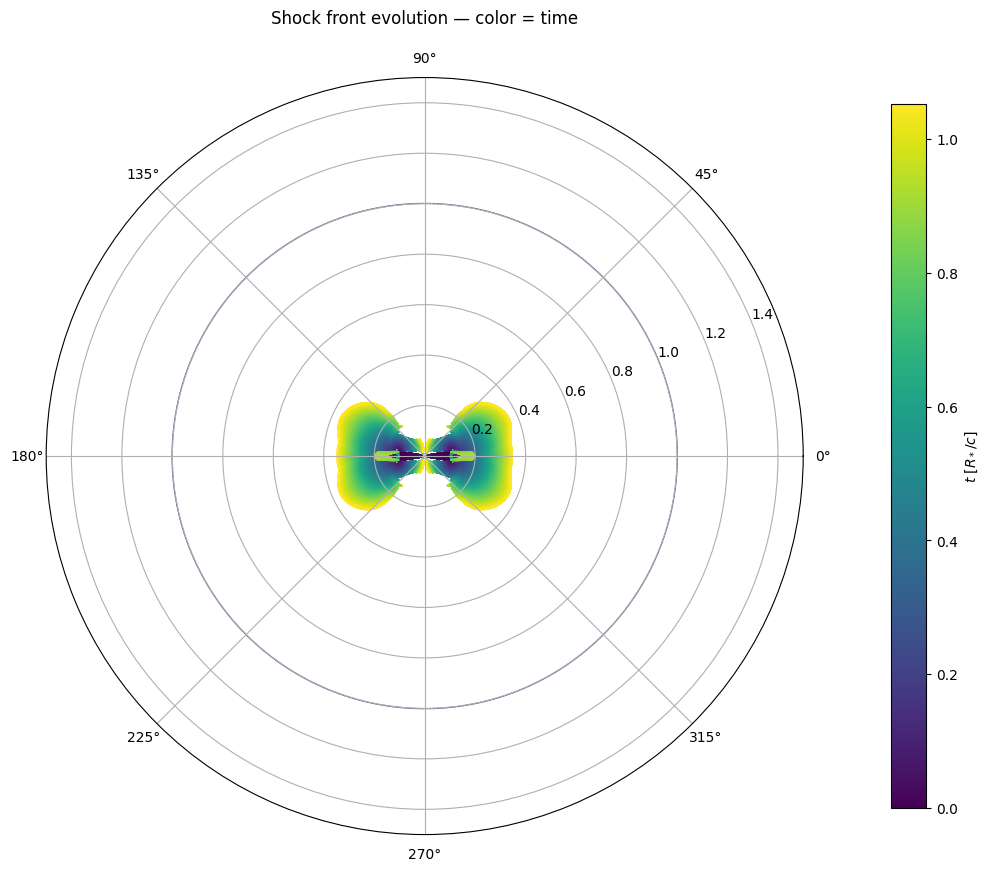

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

dt_fronts = pd.read_csv('/scratch/aripoll/athena_out/outputs/dt_shock_track_exp.csv')
dt_fronts

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 10))

sc = ax.scatter(
    np.deg2rad(dt_fronts[' phi_deg']),
    dt_fronts[' r'],
    c=dt_fronts['time'],
    cmap='viridis',
    s=1,
    linewidths=0,
    rasterized=True,
)

plt.colorbar(sc, ax=ax, label=r'$t\ [R_*/c]$', fraction=0.04, pad=0.1)
ax.set_rlim(0, 1.5)
ax.set_title(r'Shock front evolution — color = time', pad=20)
plt.tight_layout()
plt.show()

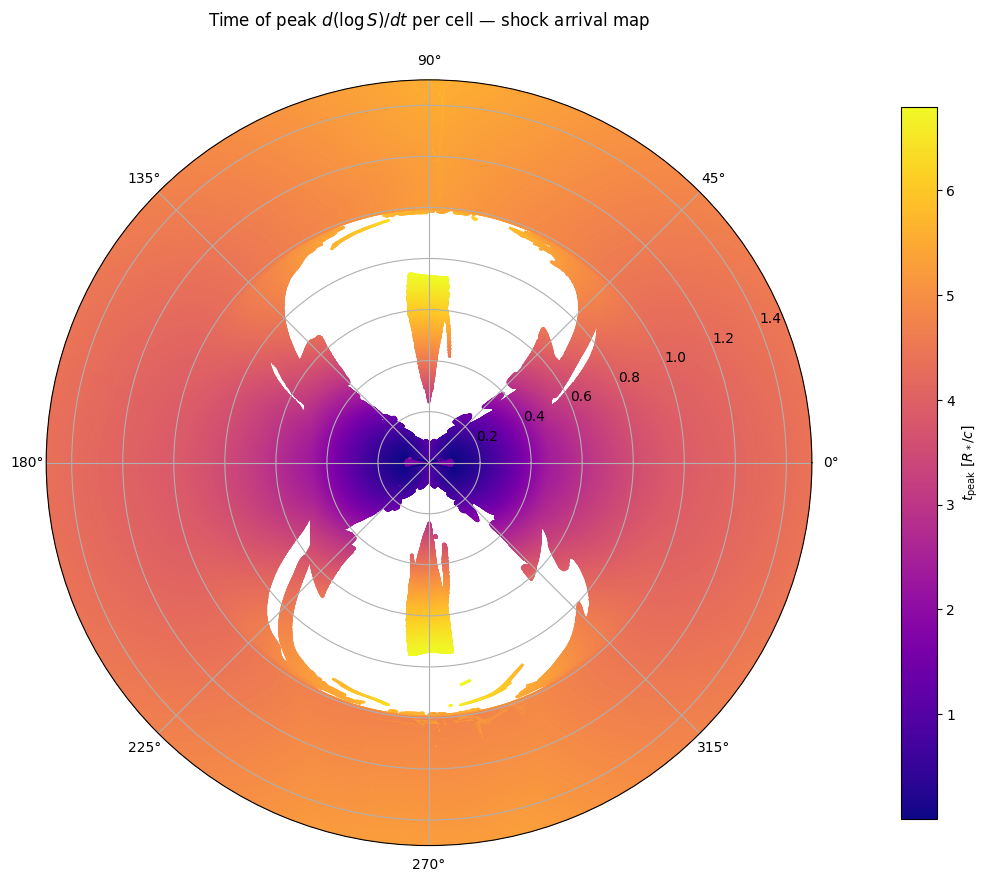

In [6]:
# For each spatial cell, find the time at which dlogS/dt was highest
peak_times = (
    dt_fronts
    .loc[dt_fronts.groupby(['r', 'phi_deg'])['dlogS_dt'].idxmax()]
    [['r', 'phi_deg', 'time', 'dlogS_dt']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 10))
sc = ax.scatter(
    np.deg2rad(peak_times['phi_deg']),
    peak_times['r'],
    c=peak_times['time'],
    cmap='plasma',
    s=4,
    linewidths=0,
    rasterized=True,
)
plt.colorbar(sc, ax=ax, label=r'$t_{\rm peak}\ [R_*/c]$', fraction=0.04, pad=0.1)
ax.set_rlim(0, 1.5)
ax.set_title(r'Time of peak $d(\log S)/dt$ per cell — shock arrival map', pad=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_745954/2845179237.py:26: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / grad_mag


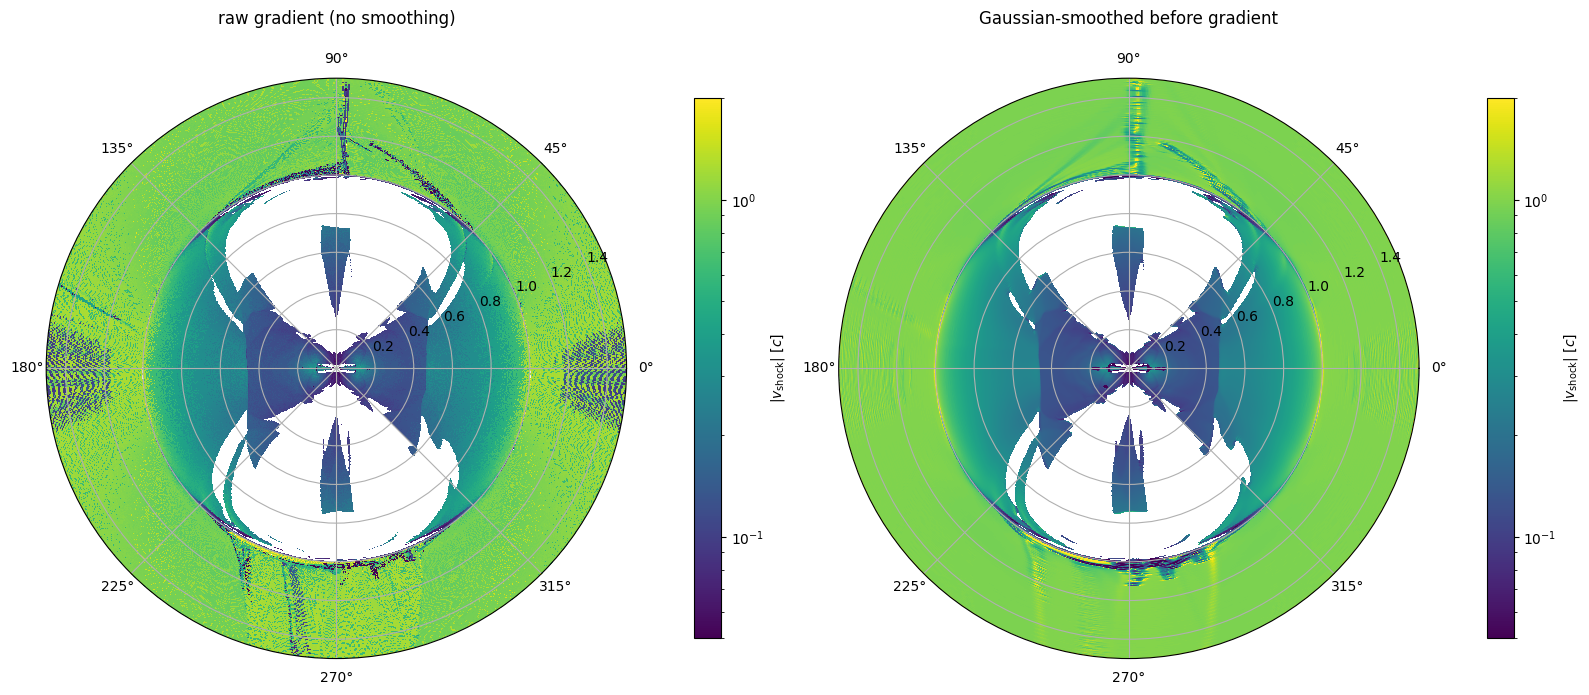

raw:      median=0.430 c,  frac > c = 14.33%
smoothed: median=0.459 c,  frac > c = 5.65%


In [7]:
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# --- Grid the scattered peak-arrival times onto the fixed (r, phi) mesh ---
# (r, phi_deg) values already sit on the simulation's regular grid; only cells that
# actually crossed the dlogS/dt threshold appear in peak_times, so missing
# combinations become NaN ("never shocked in the recorded window").
r_grid   = np.sort(peak_times['r'].unique())
phi_grid = np.sort(peak_times['phi_deg'].unique())
phi_rad  = np.deg2rad(phi_grid)
dphi     = phi_rad[1] - phi_rad[0]

T = (
    peak_times
    .pivot(index='r', columns='phi_deg', values='time')
    .reindex(index=r_grid, columns=phi_grid)
    .to_numpy()
)  # shape (nr, nphi)
mask = ~np.isnan(T)

def eikonal_speed(T, r_grid, dphi):
    """v = 1/|grad T|, grad T = (dT/dr, (1/r) dT/dphi); phi wraps (periodic domain)."""
    dTdr   = np.gradient(T, r_grid, axis=0)
    dTdphi = (np.roll(T, -1, axis=1) - np.roll(T, 1, axis=1)) / (2 * dphi)
    grad_mag = np.sqrt(dTdr**2 + (dTdphi / r_grid[:, None])**2)
    return 1.0 / grad_mag

# ---------- Method 1: raw finite differences on the un-smoothed arrival map ----------
v_raw = eikonal_speed(T, r_grid, dphi)
v_raw[~mask] = np.nan

# ---------- Method 2: smooth the arrival-time surface first, then differentiate ----------
# Normalized convolution: smooth the data and the mask with the same Gaussian kernel so
# NaN (unshocked) cells don't bias the result; mode='wrap' on the phi axis respects periodicity.
sigma = 3  # grid cells; raise to suppress more noise at the cost of front sharpness
filled     = np.where(mask, T, 0.0)
weight     = gaussian_filter(mask.astype(float), sigma=sigma, mode=['nearest', 'wrap'])
smooth_num = gaussian_filter(filled, sigma=sigma, mode=['nearest', 'wrap'])
with np.errstate(invalid='ignore', divide='ignore'):
    T_smooth = smooth_num / weight
T_smooth[weight < 0.3] = np.nan  # too little real data nearby to trust the smoothed value

v_smooth = eikonal_speed(T_smooth, r_grid, dphi)
v_smooth[np.isnan(T_smooth)] = np.nan

# ---------- Compare ----------
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(16, 8))
for ax, v, title in zip(axes, [v_raw, v_smooth],
                         ['raw gradient (no smoothing)', 'Gaussian-smoothed before gradient']):
    pm = ax.pcolormesh(
        phi_rad, r_grid, v,
        cmap='viridis', norm=mcolors.LogNorm(vmin=0.05, vmax=2.0), shading='auto',
    )
    plt.colorbar(pm, ax=ax, label=r'$|v_{\rm shock}|\ [c]$', fraction=0.04, pad=0.1)
    ax.set_rlim(0, 1.5)
    ax.set_title(title, pad=20)
plt.tight_layout()
plt.show()

print(f"raw:      median={np.nanmedian(v_raw):.3f} c,  frac > c = {np.nanmean(v_raw > 1):.2%}")
print(f"smoothed: median={np.nanmedian(v_smooth):.3f} c,  frac > c = {np.nanmean(v_smooth > 1):.2%}")

KeyboardInterrupt: 

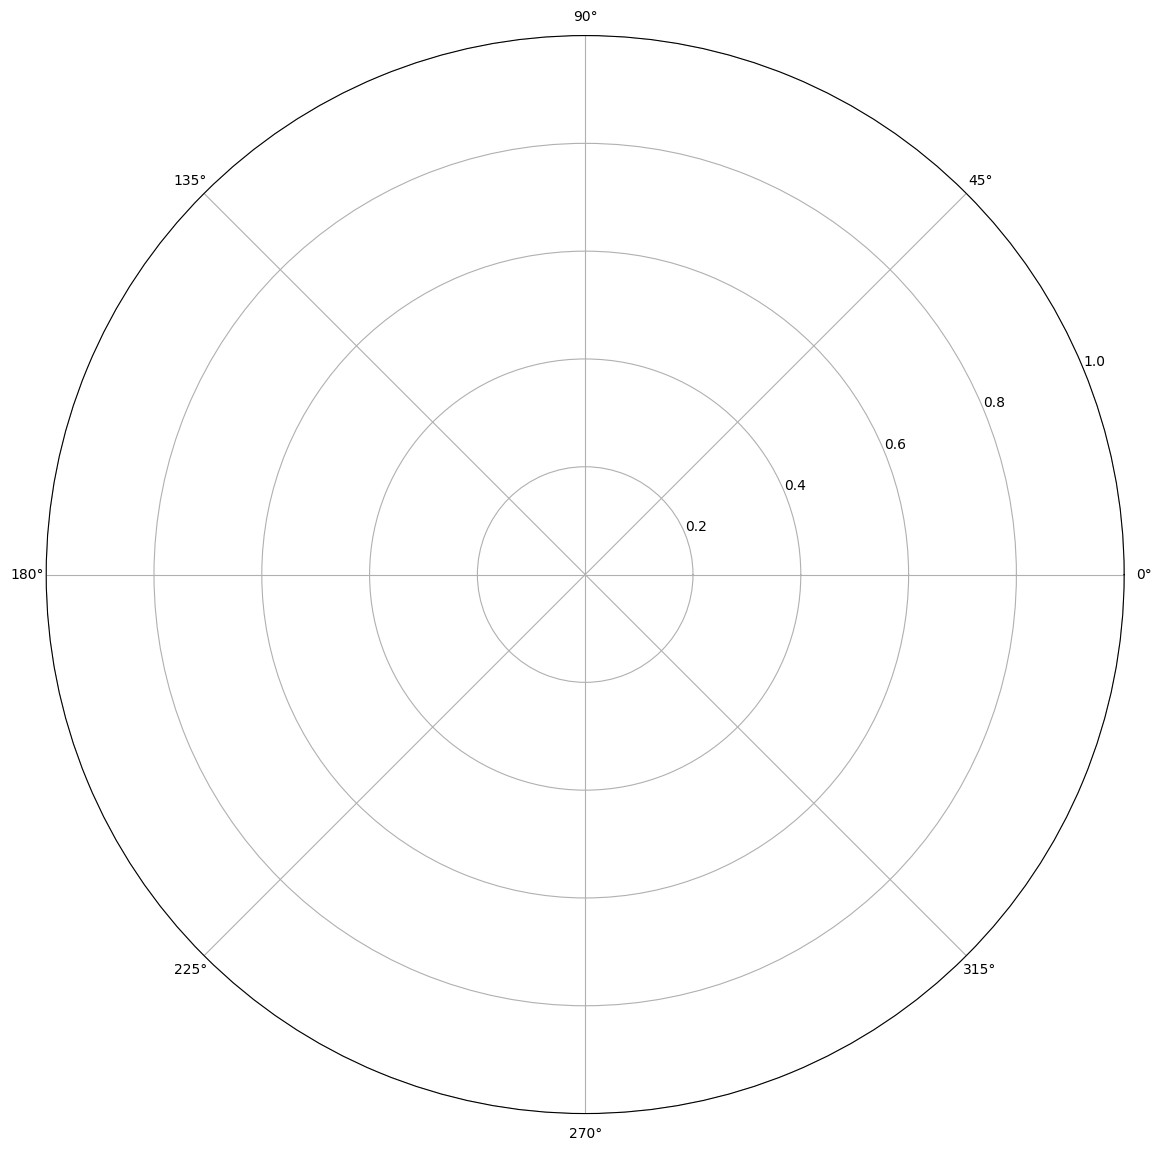

In [8]:
import subprocess
from pathlib import Path

frames_dir = Path('/scratch/aripoll/athena_out/frames_dt')
frames_dir.mkdir(parents=True, exist_ok=True)

times = sorted(dt_fronts['time'].unique())

for i, t in enumerate(times):
    frame = dt_fronts[dt_fronts['time'] == t]

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(14, 14))
    ax.scatter(
        np.deg2rad(frame['phi_deg']),
        frame['r'],
        c=frame['dlogS_dt'],
        cmap='inferno',
        norm=mcolors.LogNorm(vmin=1e3, vmax=dt_fronts['dlogS_dt'].quantile(0.999)),
        s=8,
        linewidths=0,
    )
    ax.set_rlim(0, 1.5)
    ax.set_title(rf"Shock front  $t = {t:.3f}\ R_*/c$", pad=20)
    plt.tight_layout()
    plt.savefig(frames_dir / f'frame_{i:05d}.png', dpi=80)
    plt.close()

subprocess.run([
    'ffmpeg', '-y', '-framerate', '15', '-i', str(frames_dir / 'frame_%05d.png'),
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2',
    'dt_shock_evolution.mp4'
], check=True)

from IPython.display import Video, display
display(Video('dt_shock_evolution.mp4', embed=True))

# The in-sim tracking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fronts = pd.read_csv('/scratch/aripoll/athena_out/outputs/shock_front.csv', index_col=0)
# These columns hold the SPATIAL FOUR-VELOCITY u^i = gamma*v^i, not a 3-velocity, because
# that is what Athena++ SR keeps in the primitive slots.  Older CSVs spell them vr/v_tang.
fronts = fronts.rename(columns={'vr': 'ur', 'v_tang': 'u_tang'})

def get_fronts_at(t):
    """Return shock front rows at the timestep closest to t."""
    times = fronts.index.unique()
    closest_t = times[np.argmin(np.abs(times - t))]
    df = fronts.loc[[closest_t]]
    print(f"Requested t={t:.4f}, using t={closest_t:.4f}  ({len(df)} fronts)")
    return df

def plot_fronts_at(t):
    df = get_fronts_at(t)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    ax.scatter(np.deg2rad(df['angle_deg']), df['r_shock'], marker='o', s=8, c='red')
    ax.set_rlim(0, 1.5)
    ax.set_title(rf"Shock front at $t = {df.index[0]:.3f}\ R_*/c$")
    plt.tight_layout()
    plt.show()
    return df

fronts

,angle_deg,r_shock,ur,u_tang,mushroom
time,,,,,
1.32265,1,1.002830,-0.000082,9.296100e-08,0
1.32265,3,1.002830,-0.000082,-3.725160e-08,0
1.32265,5,1.002830,-0.000080,6.101400e-10,0
1.32265,7,1.002830,-0.000082,2.453670e-08,0
1.32265,9,1.002830,-0.000078,-2.410830e-08,0
...,...,...,...,...,...
4.15229,345,0.458195,0.145907,2.430230e-02,0
4.15229,347,0.463192,0.148742,3.287830e-02,0
4.15229,349,0.473185,0.161802,5.717490e-02,0


yt : [WARNING  ] 2026-09-23 12:45:39,310 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:45:39,311 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:45:39,312 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:45:39,312 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-09-23 12:45:39,332 Parameters: current_time              = 1.7780110710113814
yt : [INFO     ] 2026-09-23 12:45:39,332 Parameters: domain_dimensions         = [2400 1200    1]
yt : [INFO     ] 2026-09-23 12:45:39,332 Parameters: domain_left_edge          = [0.01 0.   0.  ]
yt : [INFO     ] 2026-09-23 12:45:39,333 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-09-23 12:45:39,333 Parameters: cosmological_simulation   = 0


yt : [WARNING  ] 2026-09-23 12:45:39,790 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:45:39,790 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:45:39,791 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:45:39,791 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-09-23 12:45:39,811 Parameters: current_time              = 1.8890166095521632
yt : [INFO     ] 2026-09-23 12:45:39,811 Parameters: domain_dimensions         = [2400 1200    1]
yt : [INFO     ] 2026-09-23 12:45:39,811 Parameters: domain_left_edge          = [0.01 0.   0.  ]
yt : [INFO     ] 2026-09-23 12:45:39,812 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-09-23 12:45:39,812 Parameters: cosmological_simulation   = 0


(0.8, 1.5)

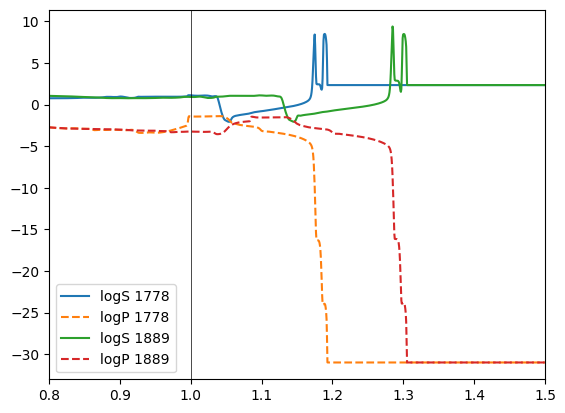

In [36]:
import yt, numpy as np, matplotlib.pyplot as plt
for n in (1778, 1889):  # dumps at t=1.778 and t=1.889
    ds = yt.load(f'/scratch/aripoll/athena_out/outputs/jb_exp.out1.{n:05d}.athdf')
    cg = ds.covering_grid(0, ds.domain_left_edge, ds.domain_dimensions)
    r = cg['index', 'r'].v[:, 0, 0]
    j = 0  # phi index nearest 0 deg
    rho, p = cg['athena_pp', 'rho'].v[:, j, 0], cg['athena_pp', 'press'].v[:, j, 0]
    logS = np.log10(p / rho**(4/3))
    plt.plot(r, logS, label=f'logS {n}')
    plt.plot(r, np.log10(p), '--', label=f'logP {n}')
plt.axvline(1.0, c='k', lw=.5); plt.legend(); plt.xlim(0.8, 1.5)

In [37]:
import yt, numpy as np
for n in (1778, 1889):
    ds = yt.load(f'/scratch/aripoll/athena_out/outputs/jb_exp.out1.{n:05d}.athdf')
    cg = ds.covering_grid(0, ds.domain_left_edge, ds.domain_dimensions)
    r   = cg['index', 'r'].v[:, 0, 0]
    phi = cg['index', 'theta'].v[0, :, 0]
    S   = cg['athena_pp', 'press'].v[:, :, 0] / cg['athena_pp', 'rho'].v[:, :, 0]**(4/3)
    js  = phi < np.deg2rad(2.0)                        # angular bin 0 (0-2 deg)
    rmin, rmax, nr = 1e-3, 1.5, 300; dr = (rmax - rmin) / nr
    ri  = ((r - rmin) / dr).astype(int)
    L   = np.array([np.log10(S[ri == k][:, js]).mean() if (ri == k).any() else np.nan
                    for k in range(nr)])
    g   = np.abs((L[2:] - L[:-2]) / (2 * dr))
    rb  = rmin + (np.arange(1, nr - 1) + 0.5) * dr
    m   = (rb > 1.0) & (rb < 1.4)
    print(n, np.c_[rb[m], L[1:-1][m], g[m]].round(2)[g[m] > 20])

yt : [WARNING  ] 2026-09-23 12:47:47,845 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:47:47,846 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:47:47,846 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:47:47,846 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-09-23 12:47:47,866 Parameters: current_time              = 1.7780110710113814
yt : [INFO     ] 2026-09-23 12:47:47,866 Parameters: domain_dimensions         = [2400 1200    1]
yt : [INFO     ] 2026-09-23 12:47:47,867 Parameters: domain_left_edge          = [0.01 0.   0.  ]
yt : [INFO     ] 2026-09-23 12:47:47,867 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-09-23 12:47:47,867 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-09-23 12:47:48,170 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:47:48,170 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:47:48,171 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:47:48,171 Assuming 1.0 = 1.0 K
yt : [I

1778 [[ 1.0300e+00  1.0000e+00  3.7520e+01]
 [ 1.0400e+00  6.4000e-01  1.8181e+02]
 [ 1.0400e+00 -8.2000e-01  2.4360e+02]
 [ 1.0500e+00 -1.8000e+00  1.2160e+02]
 [ 1.0600e+00 -1.6600e+00  6.6940e+01]
 [ 1.0600e+00 -1.3700e+00  3.8480e+01]
 [ 1.0800e+00 -1.0700e+00  2.1010e+01]
 [ 1.1500e+00 -1.2000e-01  2.0190e+01]
 [ 1.1500e+00 -1.0000e-02  2.4830e+01]
 [ 1.1600e+00  1.3000e-01  3.2840e+01]
 [ 1.1600e+00  3.2000e-01  6.2560e+01]
 [ 1.1700e+00  7.6000e-01  4.7740e+02]
 [ 1.1700e+00  5.0900e+00  2.5483e+02]
 [ 1.1800e+00  3.3000e+00  2.8856e+02]
 [ 1.1800e+00  2.2100e+00  3.5269e+02]
 [ 1.1900e+00  6.8300e+00  2.2334e+02]
 [ 1.1900e+00  4.4400e+00  4.4958e+02]
 [ 1.2000e+00  2.3300e+00  2.1071e+02]]
1889 [[ 1.1200e+00  1.0000e+00  2.6800e+01]
 [ 1.1300e+00  7.9000e-01  1.4290e+02]
 [ 1.1300e+00 -4.3000e-01  2.4153e+02]
 [ 1.1400e+00 -1.6300e+00  1.5683e+02]
 [ 1.1400e+00 -1.9900e+00  2.0190e+01]
 [ 1.1500e+00 -1.8300e+00  6.5970e+01]
 [ 1.1500e+00 -1.3300e+00  5.3830e+01]
 [ 1.2600e+00 

Requested t=1.0000, using t=1.0000  (180 fronts)


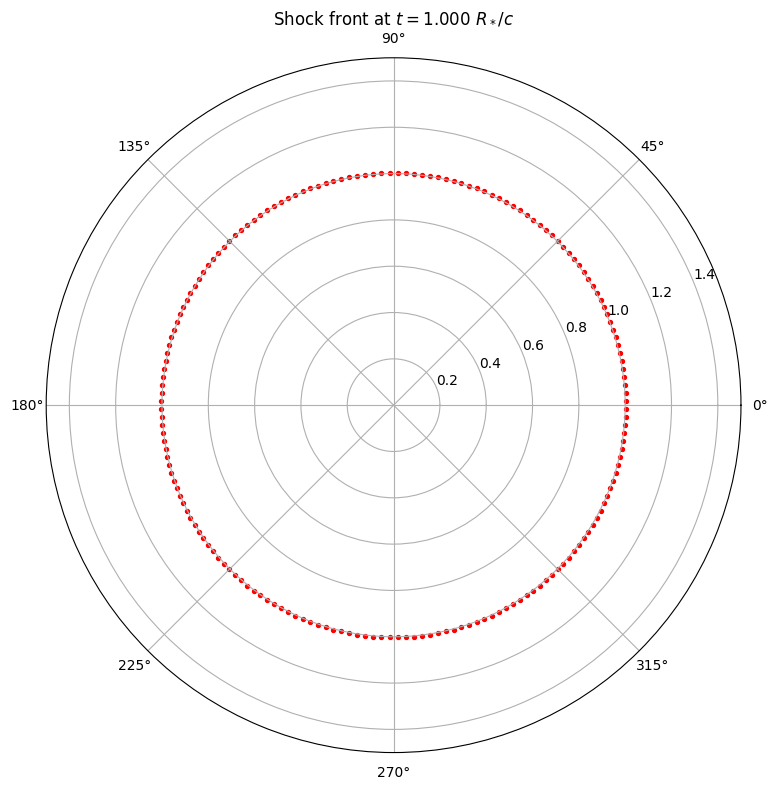

Requested t=1.0526, using t=1.0528  (180 fronts)


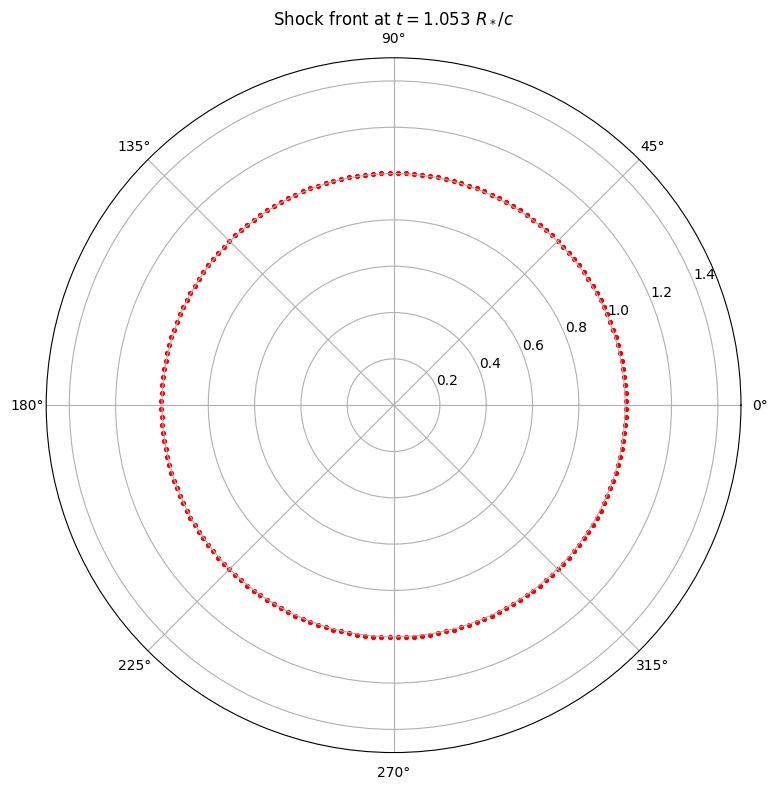

Requested t=1.1053, using t=1.1056  (180 fronts)


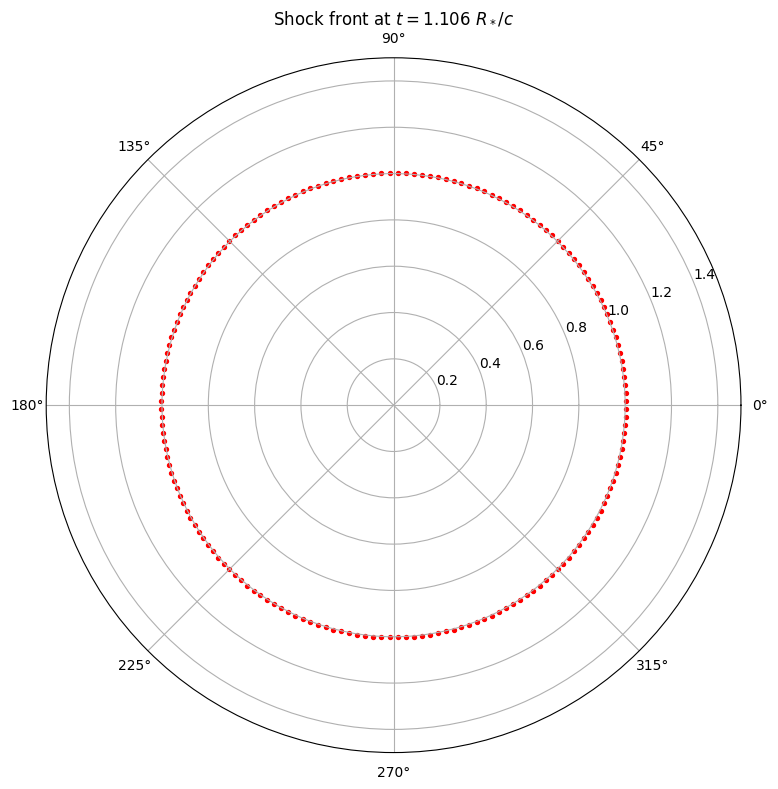

Requested t=1.1579, using t=1.1584  (180 fronts)


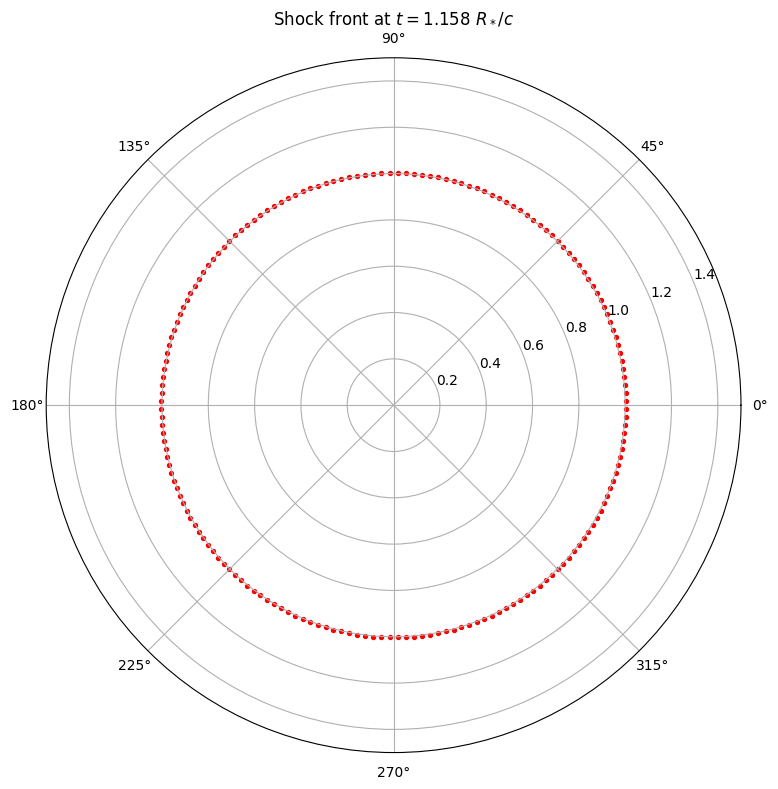

Requested t=1.2105, using t=1.2102  (180 fronts)


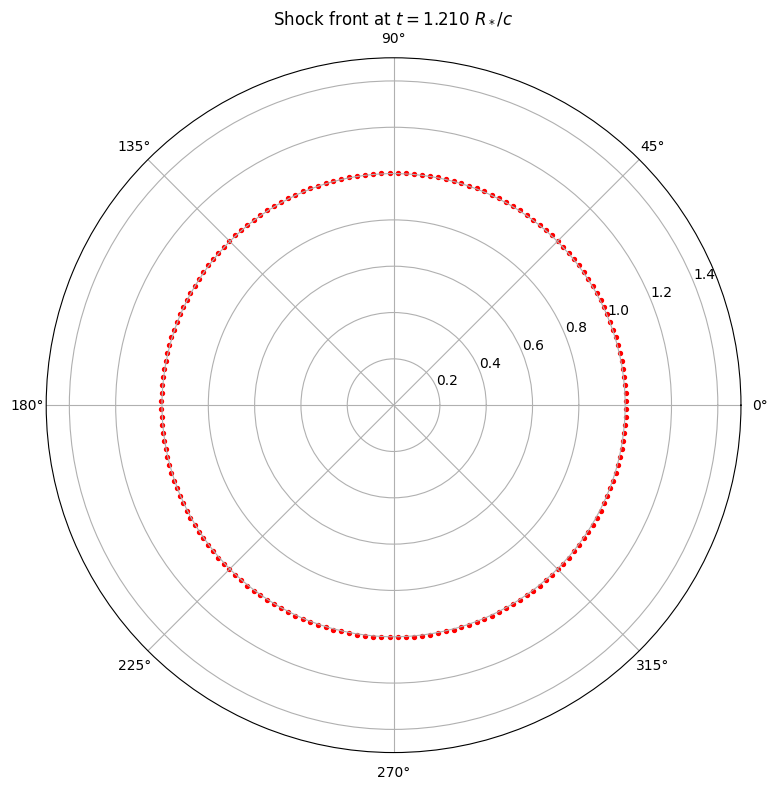

Requested t=1.2632, using t=1.2629  (192 fronts)


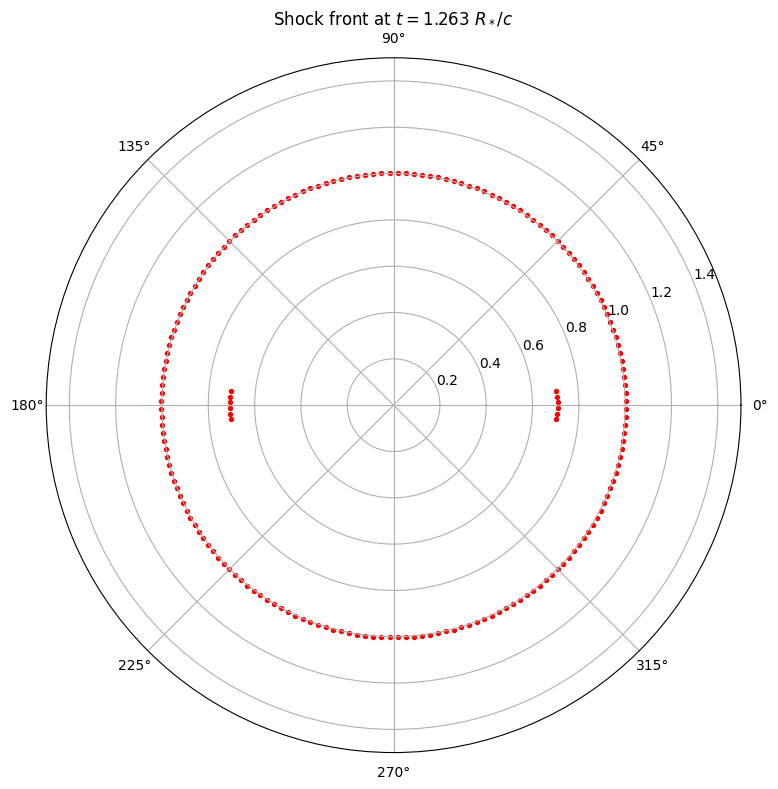

Requested t=1.3158, using t=1.3157  (208 fronts)


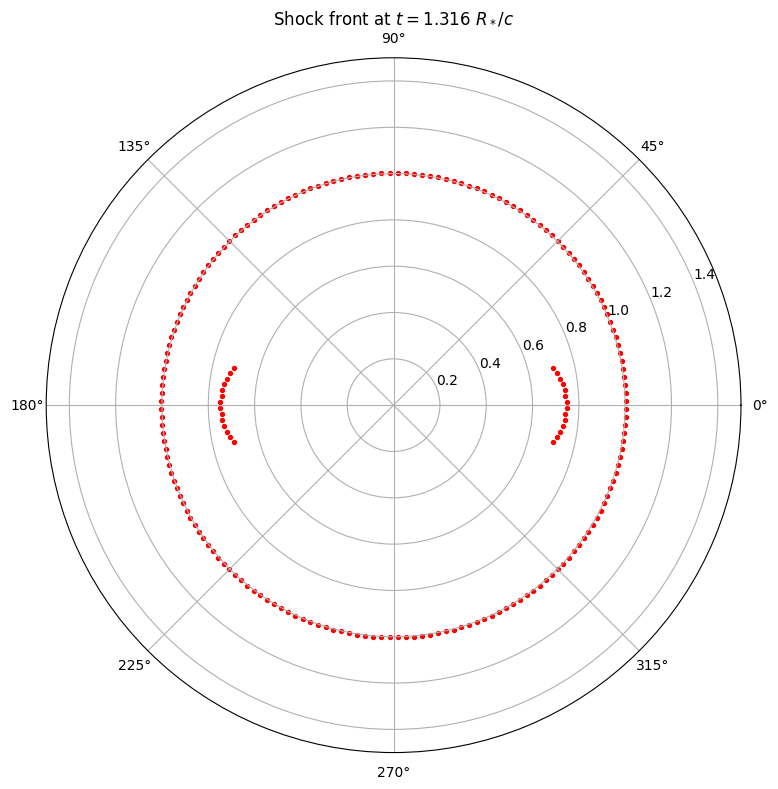

Requested t=1.3684, using t=1.3685  (232 fronts)


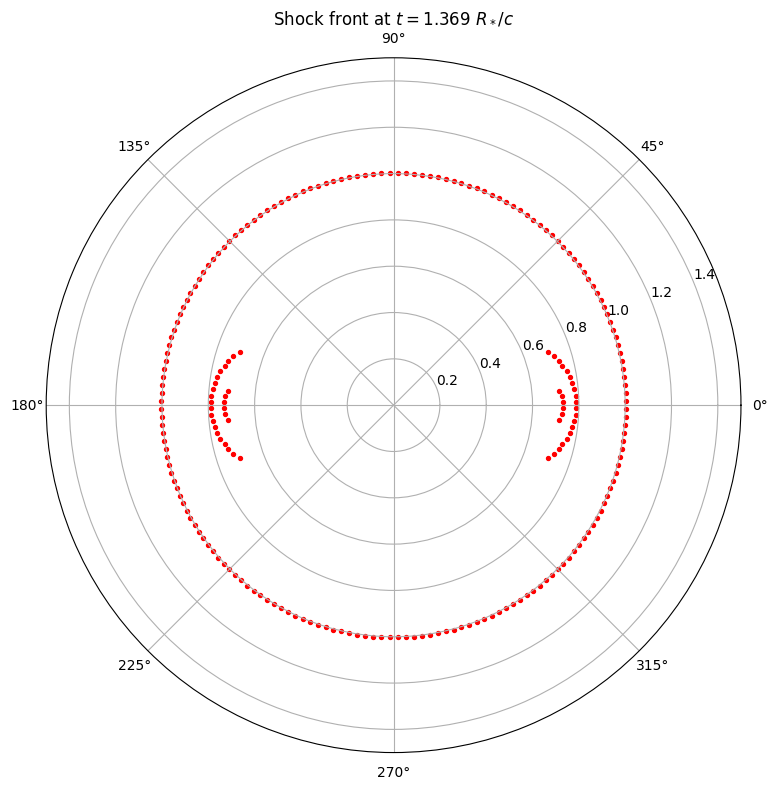

Requested t=1.4211, using t=1.4213  (240 fronts)


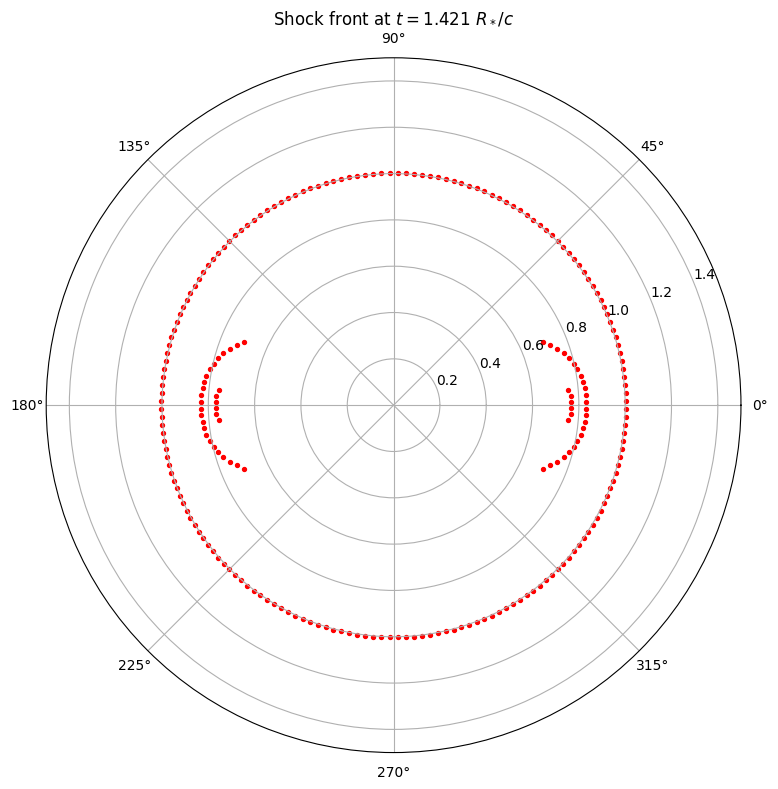

Requested t=1.4737, using t=1.4741  (180 fronts)


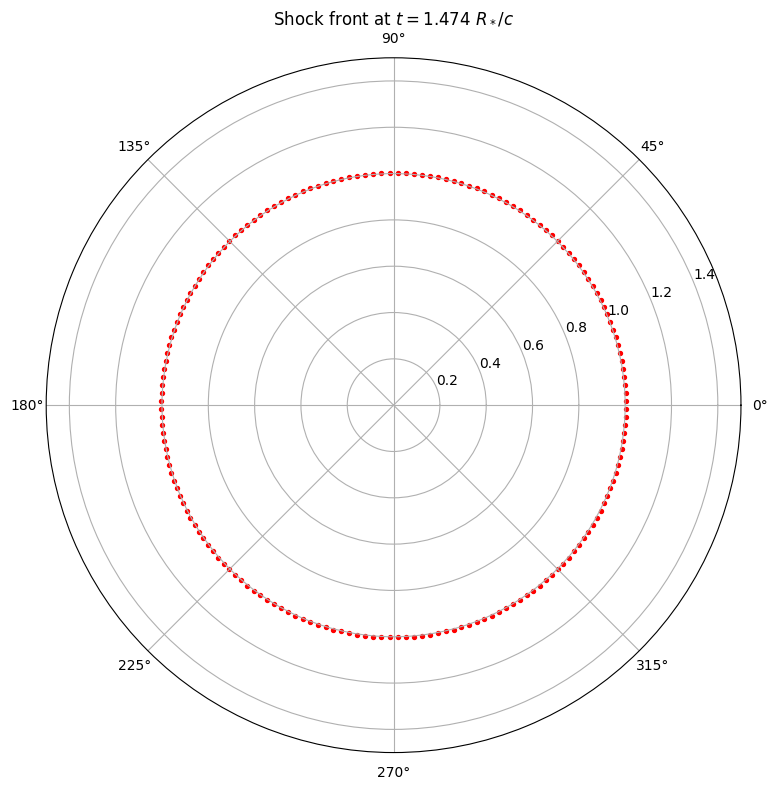

Requested t=1.5263, using t=1.5266  (180 fronts)


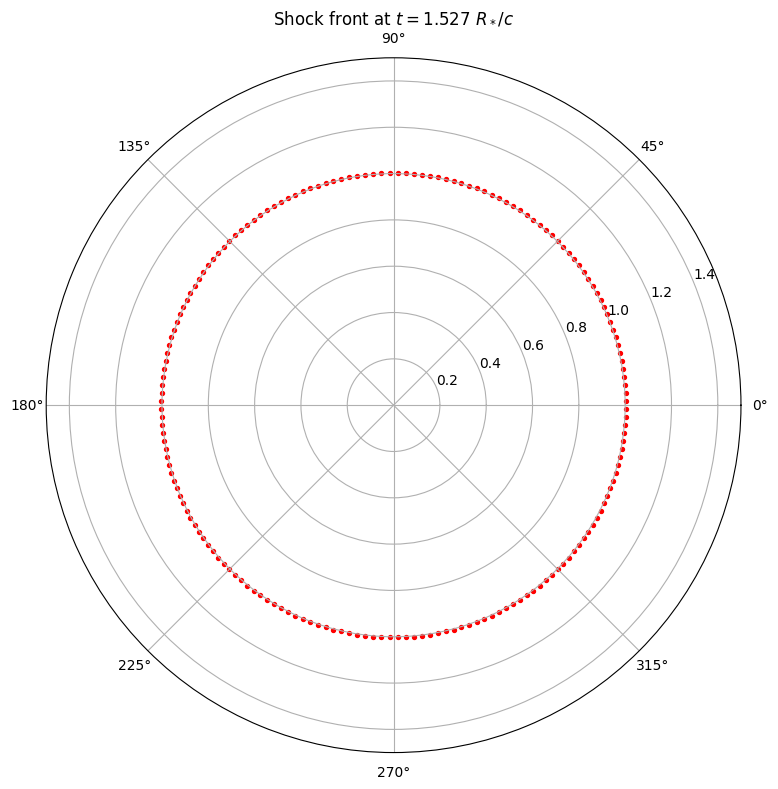

Requested t=1.5789, using t=1.5791  (181 fronts)


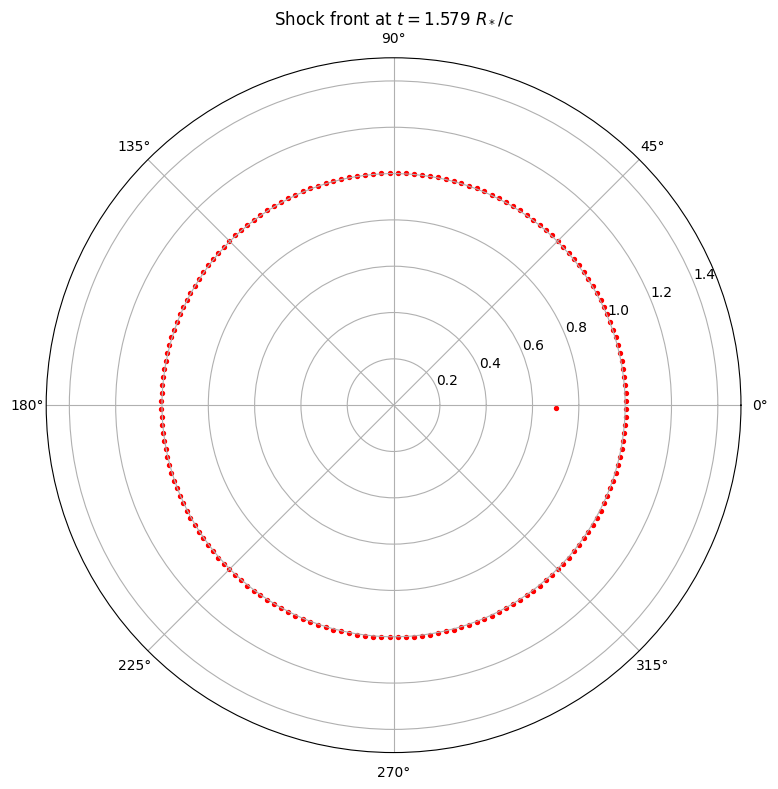

Requested t=1.6316, using t=1.6317  (200 fronts)


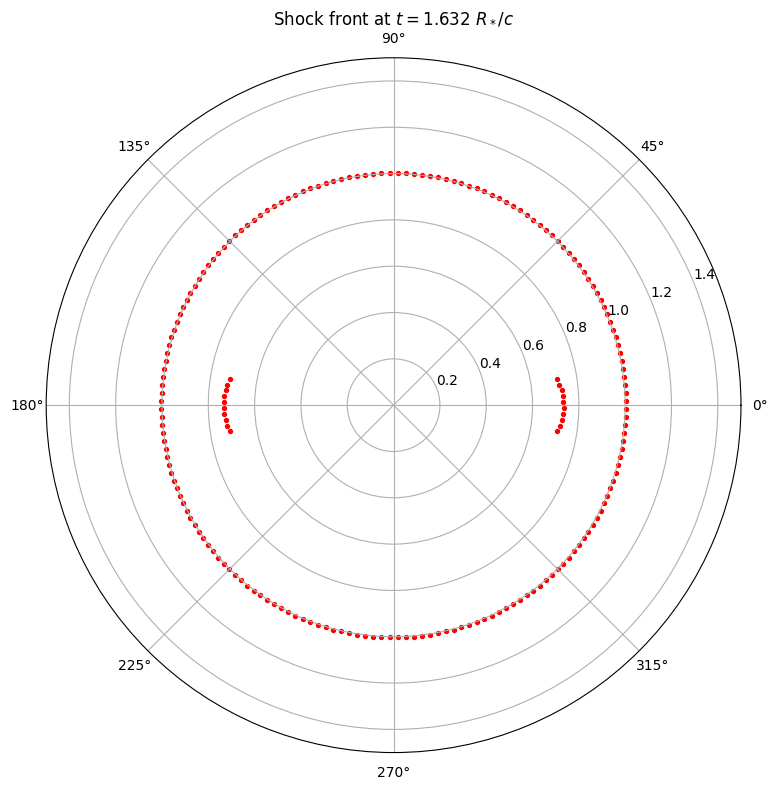

Requested t=1.6842, using t=1.6842  (220 fronts)


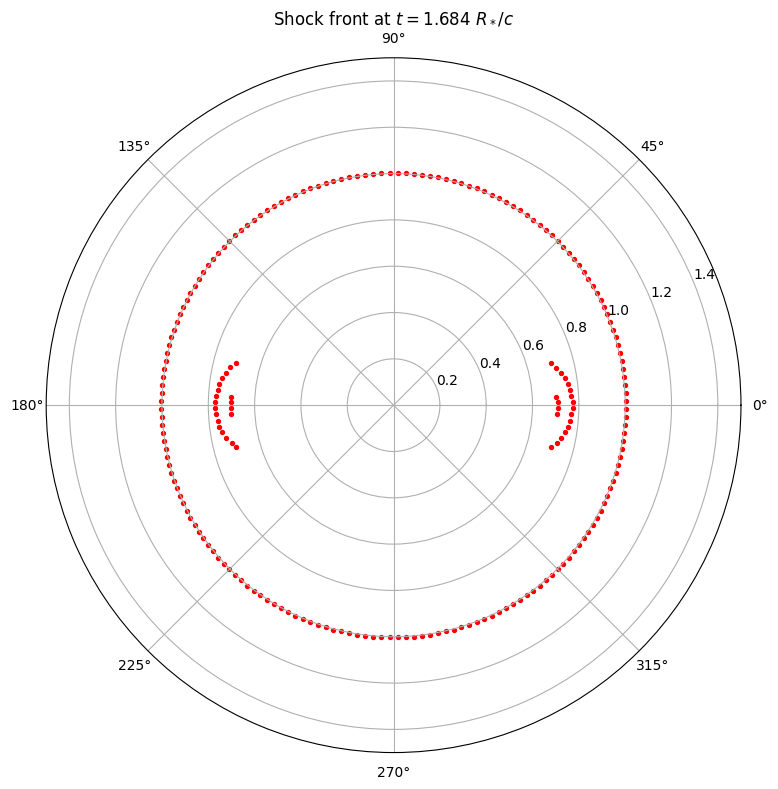

Requested t=1.7368, using t=1.7368  (232 fronts)


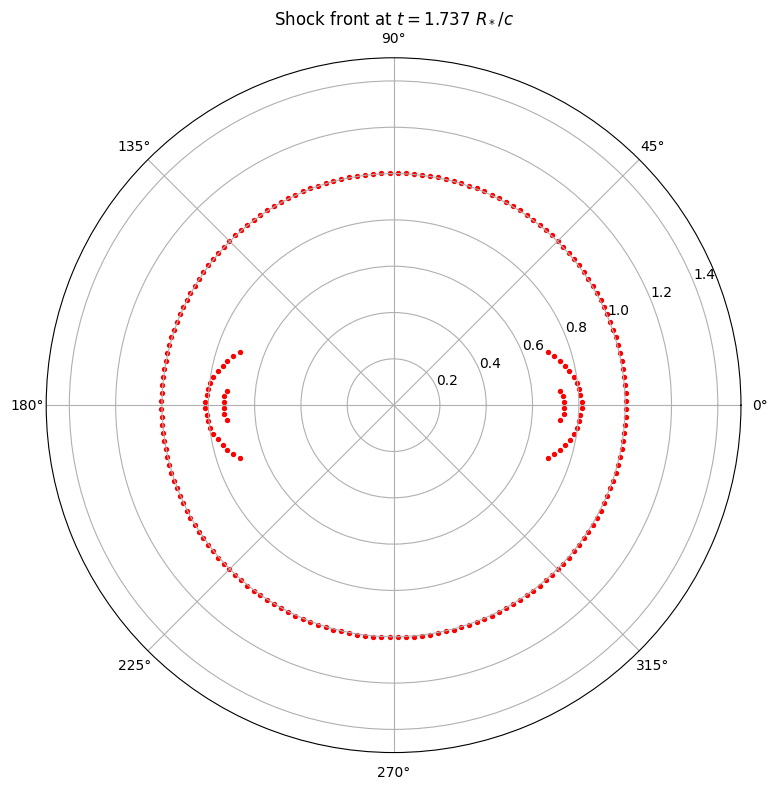

Requested t=1.7895, using t=1.7893  (236 fronts)


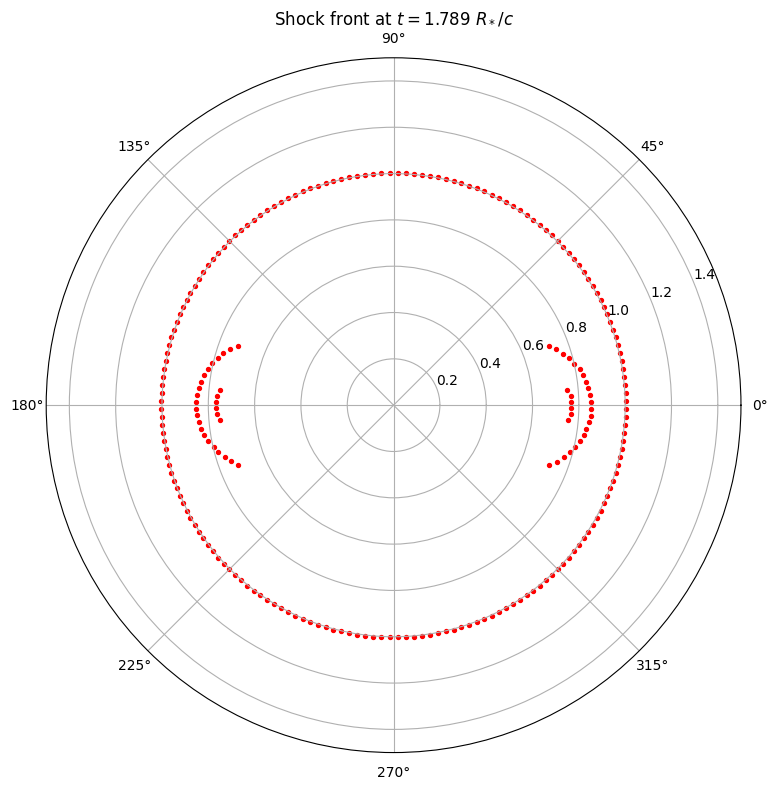

Requested t=1.8421, using t=1.8418  (242 fronts)


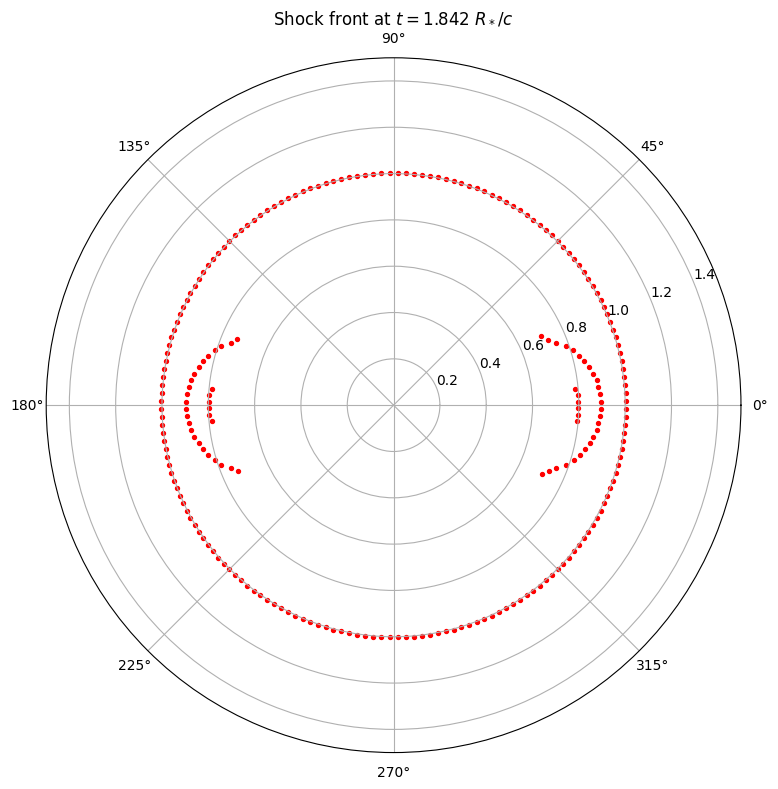

Requested t=1.8947, using t=1.8944  (200 fronts)


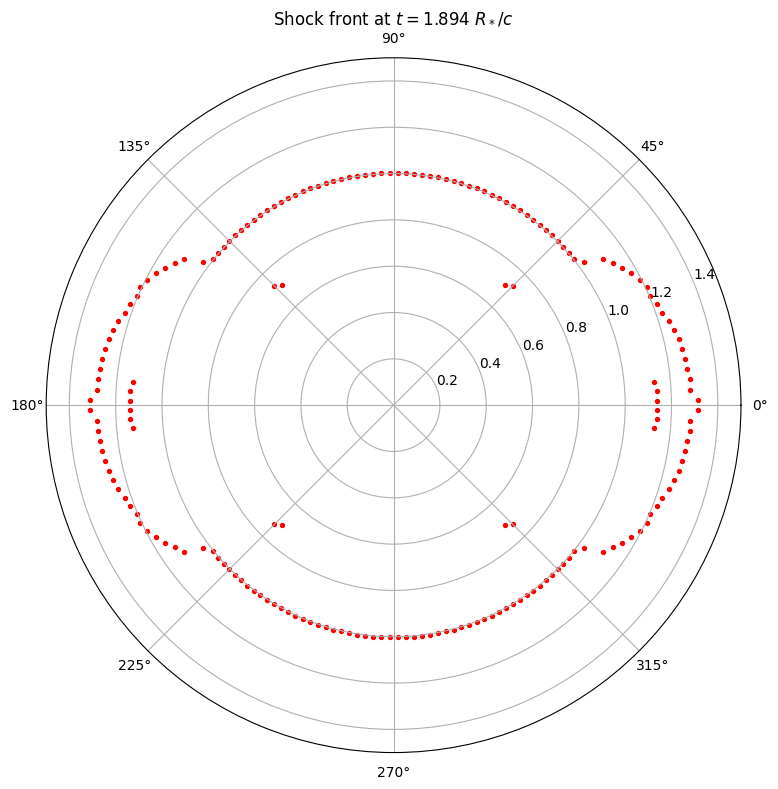

Requested t=1.9474, using t=1.9472  (204 fronts)


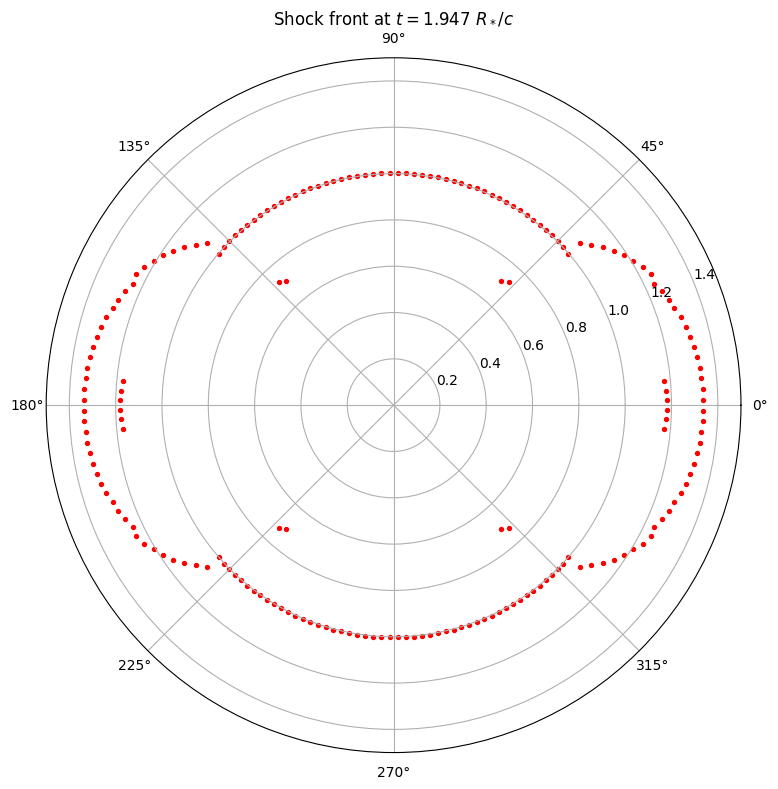

Requested t=2.0000, using t=2.0000  (212 fronts)


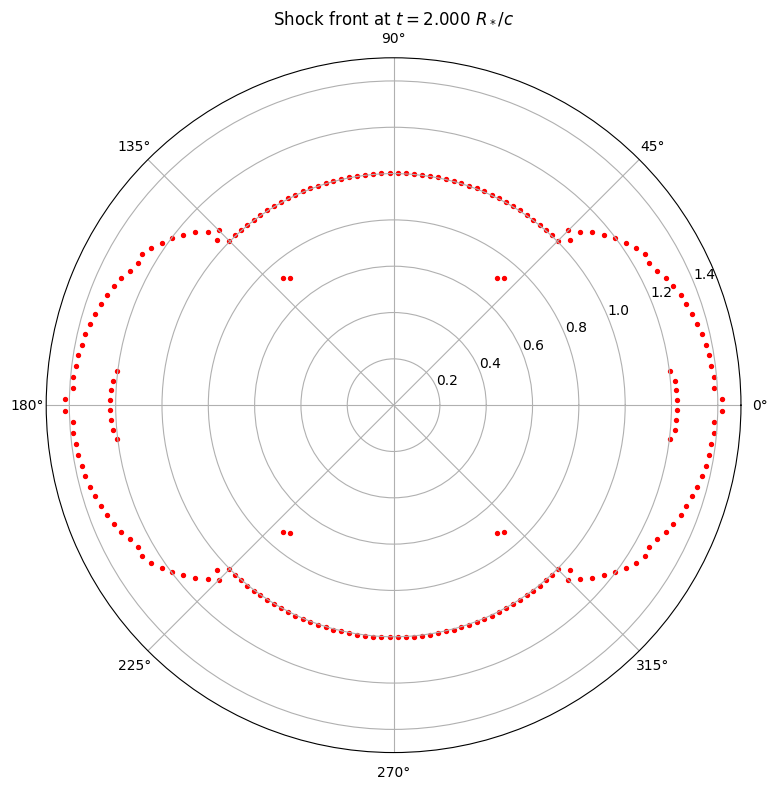

In [ ]:

#Now make a movie of the shock front evolution
t = np.linspace(1.0, 2.0, 20)
for t in t:
    plot_fronts_at(t)

In [14]:
dr = (1.5 - 1e-3) / 2400
dr

0.0006245833333333333

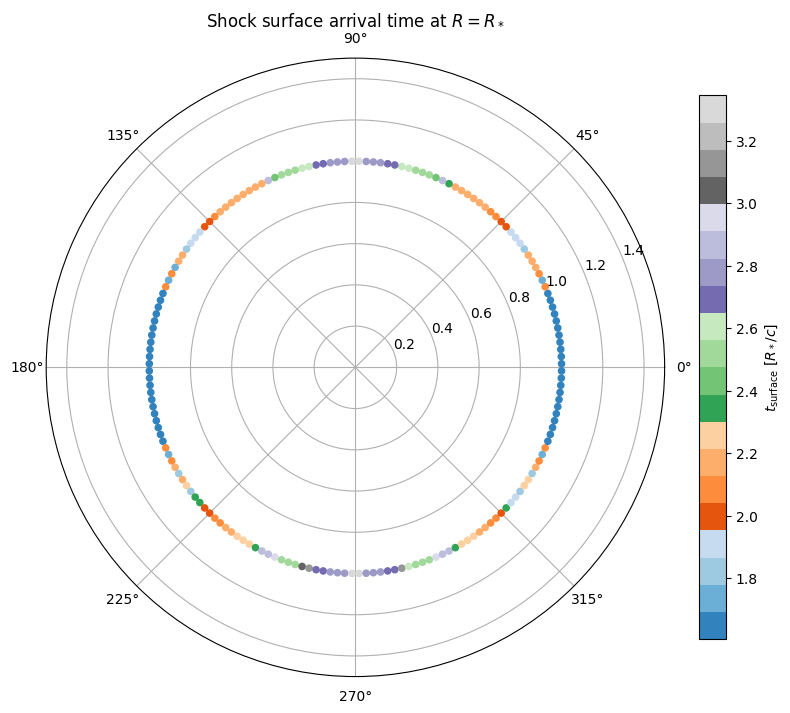

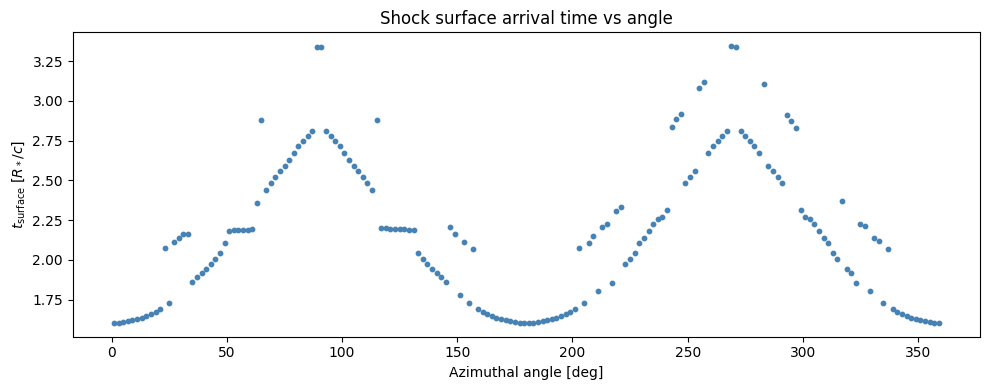

        time  angle_deg   r_shock         ur     u_tang  mushroom      u_mag
0    1.60406          1  1.002830   4.185190   0.094469         0   4.186256
1    1.60609          3  1.002830   4.260680   0.275305         0   4.269565
2    1.60914          5  1.002830   4.127710   0.432246         0   4.150280
3    1.61421          7  1.002830   3.981510   0.592134         0   4.025301
4    1.62031          9  1.002830   3.872370   0.746909         0   3.943745
5    1.62843         11  1.002830   3.698290   0.891654         0   3.804260
6    1.63756         13  1.002830   3.434260   1.028120         0   3.584853
7    1.64670         15  1.002830   3.117850   1.119180         0   3.312635
8    1.65990         17  1.002830   2.962030   1.218530         0   3.202879
9    1.67513         19  1.002830   2.724270   1.274260         0   3.007555
10   1.69036         21  1.002830   2.504900   1.303050         0   2.823555
11   2.07668         23  1.002830   1.532920   6.663960         0   6.837997

In [4]:
def surface_arrival_rows(r_tol=5e-3):
    """
    For each angular bin, find the timestep of peak four-velocity magnitude near R=1.
    Peak |u| marks when the shock is actively crossing the cell, not just nearby.

    ur and u_tang are PHYSICAL (orthonormal) components, so the magnitude is the plain
    Pythagorean sum with no metric factors.  The 1/r factors belong to the gradient,
    |grad f|^2 = (df/dr)^2 + (1/r^2)(df/dphi)^2, not to a physical-component vector.

    |u| = gamma*|v| is NOT a speed and is unbounded above.  It is monotonic in |v|, so
    the argmax (and therefore the arrival time) is the same either way; convert with
    v = u_mag / sqrt(1 + u_mag**2) if you need an actual 3-speed.
    """
    near = fronts[np.abs(fronts['r_shock'] - 1.0) < r_tol].reset_index()
    near['u_mag'] = np.sqrt(near['ur']**2 + near['u_tang']**2)
    return near.loc[near.groupby('angle_deg')['u_mag'].idxmax()].reset_index(drop=True)

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
arr


# Polar plot: each angle dot coloured by arrival time
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
sc = ax.scatter(
    np.deg2rad(arr['angle_deg']), np.ones(len(arr)),
    c=arr['time'], cmap='tab20c', s=20, zorder=3
)
ax.set_rlim(0, 1.5)
ax.set_title(r"Shock surface arrival time at $R = R_*$")
plt.colorbar(sc, ax=ax, label=r'$t_{\rm surface}\ [R_*/c]$', fraction=0.04)
plt.tight_layout()
plt.show()

# Cartesian: angle vs arrival time (easier to read exact values)
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(arr['angle_deg'], arr['time'], s=10, c='steelblue')
ax.set_xlabel(r'Azimuthal angle [deg]')
ax.set_ylabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_title(r'Shock surface arrival time vs angle')
plt.tight_layout()
plt.show()

print(arr.to_string())

In [11]:
dr = (1.5 - 1e-3) / 2400
dr

0.0006245833333333333

First subluminal point: phi = 21.000 deg (0.3665 rad), t_surface = 1.6904 R_*/c


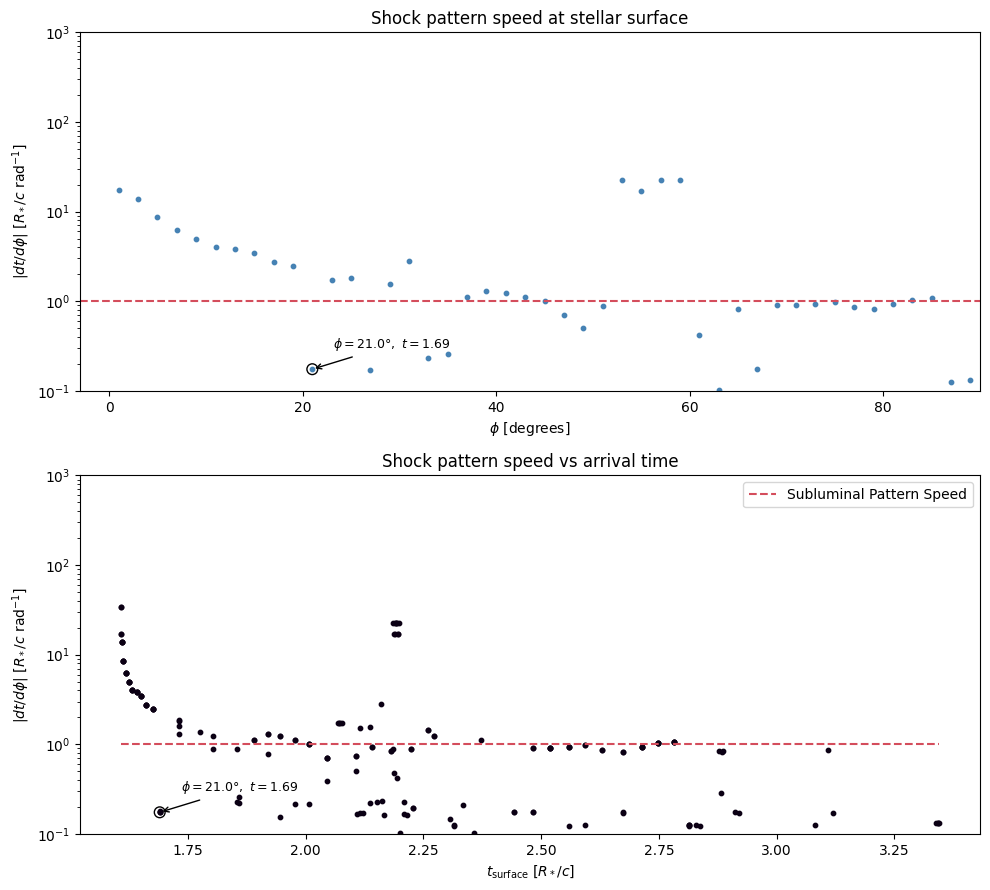

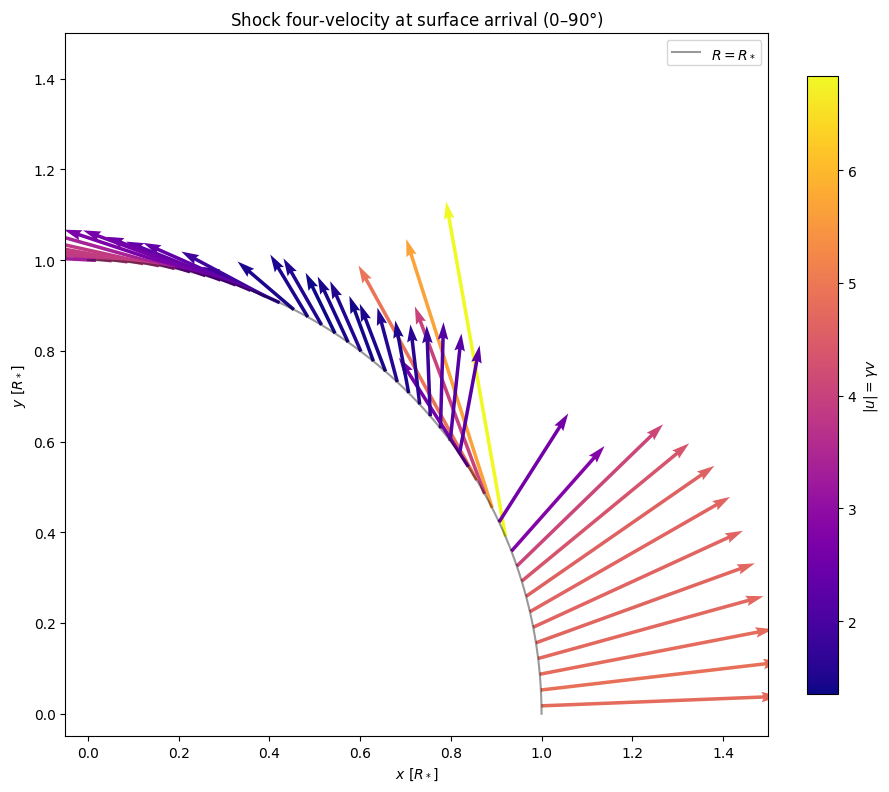

In [ ]:
def surface_arrival_rows(r_tol=0.005):
    near = fronts[np.abs(fronts['r_shock'] - 1.0) < r_tol].reset_index()
    near['u_mag'] = np.sqrt(near['ur']**2 + near['u_tang']**2)
    return near.loc[near.groupby('angle_deg')['u_mag'].idxmax()].reset_index(drop=True)

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
arr

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
phi_rad = np.deg2rad(arr['angle_deg'].values)
t_surf  = arr['time'].values

# ---- 1. Pattern speed: t_surface vs 1/speed = dt/dphi ----
dt_dphi = np.gradient(t_surf, phi_rad)          # [R_*/c per rad]
# at R=1 the linear pattern speed along the surface is dphi/dt [c]
pattern_speed = 1.0 / np.abs(dt_dphi)

# ---- First point (in angle order) where the pattern speed drops below c ----
sub_idx = np.where(pattern_speed < 1)[0]
i0 = sub_idx[0]
phi_deg_star = arr['angle_deg'].values[i0]
phi_rad_star = phi_rad[i0]
t_star = t_surf[i0]
print(f"First subluminal point: phi = {phi_deg_star:.3f} deg ({phi_rad_star:.4f} rad), "
      f"t_surface = {t_star:.4f} R_*/c")

fig, ax = plt.subplots(2, 1, figsize=(10, 9))
ax[0].scatter(arr['angle_deg'], pattern_speed, s=10, c='steelblue')
ax[0].set_xlim(-3, 90)
ax[0].set_yscale('log')
ax[0].set_ylim(0.1, 1e3)
ax[0].set_xlabel(r'$\phi\ [\mathrm{degrees}]$')
ax[0].set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
ax[0].set_title(r'Shock pattern speed at stellar surface')
ax[0].hlines(1.0, -3, 90, colors='#D44D5C', linestyles='dashed', label='Subluminal Pattern Speed')
ax[0].scatter([phi_deg_star], [pattern_speed[i0]], s=60, facecolors='none', edgecolors='black', zorder=5)
ax[0].annotate(rf'$\phi={phi_deg_star:.1f}°,\ t={t_star:.2f}$',
               xy=(phi_deg_star, pattern_speed[i0]), xytext=(15, 15),
               textcoords='offset points', fontsize=9,
               arrowprops=dict(arrowstyle='->', color='black'))

ax[1].scatter(t_surf, pattern_speed, s=10, c='#0B0014')
ax[1].set_yscale('log')
ax[1].set_ylim(0.1, 1e3)
ax[1].set_xlabel(r'$t_{\rm surface}\ [R_*/c]$')
ax[1].set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
ax[1].set_title(r'Shock pattern speed vs arrival time')
ax[1].hlines(1.0, t_surf.min(), t_surf.max(), colors='#D44D5C', linestyles='dashed', label='Subluminal Pattern Speed')
ax[1].scatter([t_star], [pattern_speed[i0]], s=60, facecolors='none', edgecolors='black', zorder=5)
ax[1].annotate(rf'$\phi={phi_deg_star:.1f}°,\ t={t_star:.2f}$',
               xy=(t_star, pattern_speed[i0]), xytext=(15, 15),
               textcoords='offset points', fontsize=9,
               arrowprops=dict(arrowstyle='->', color='black'))

plt.legend()
plt.tight_layout()
plt.savefig('patt_speed.svg')
plt.show()

# ---- 2. Velocity quivers at surface, 0–90° only ----
q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
phi_q = np.deg2rad(q['angle_deg'].values)

# Position on unit circle
x_pos = np.cos(phi_q)
y_pos = np.sin(phi_q)

# Decompose into Cartesian: e_r = (cosφ, sinφ), e_φ = (−sinφ, cosφ)
ur  = q['ur'].values
ut  = q['u_tang'].values
ux  = ur * np.cos(phi_q) - ut * np.sin(phi_q)
uy  = ur * np.sin(phi_q) + ut * np.cos(phi_q)
u_mag = np.sqrt(ux**2 + uy**2)          # = gamma*|v|, not a speed

# Scale so the largest arrow is 0.15 R_* long
arrow_scale = 0.15 / u_mag.max() if u_mag.max() > 0 else 1.0


fig, ax = plt.subplots(figsize=(9, 9))
theta_arc = np.linspace(0, np.pi/2, 300)
ax.plot(np.cos(theta_arc), np.sin(theta_arc), 'k-', lw=1.5, alpha=0.4, label=r'$R = R_*$')
qv = ax.quiver(
    x_pos, y_pos,
    ux * arrow_scale, uy * arrow_scale,
    u_mag, cmap='plasma',
    angles='xy', scale_units='xy', scale=0.2,
    width=0.005, clim=(u_mag.min(), u_mag.max())
)
plt.colorbar(qv, ax=ax, label=r'$|u| = \gamma v$', fraction=0.04)
ax.set_xlim(-0.05, 1.5)
ax.set_ylim(-0.05, 1.5)
ax.set_aspect('equal')
ax.set_xlabel(r'$x\ [R_*]$')
ax.set_ylabel(r'$y\ [R_*]$')
ax.set_title(r'Shock four-velocity at surface arrival ($0$–$90°$)')
ax.legend(loc='upper right')
plt.tight_layout()
# # plt.savefig('shock_velocities.svg')
# plt.show()

yt : [WARNING  ] 2026-09-23 12:20:27,537 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-09-23 12:20:27,538 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-09-23 12:20:27,538 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-09-23 12:20:27,538 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-09-23 12:20:27,558 Parameters: current_time              = 1.690010182897907
yt : [INFO     ] 2026-09-23 12:20:27,558 Parameters: domain_dimensions         = [2400 1200    1]
yt : [INFO     ] 2026-09-23 12:20:27,558 Parameters: domain_left_edge          = [0.01 0.   0.  ]
yt : [INFO     ] 2026-09-23 12:20:27,559 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-09-23 12:20:27,559 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2026-09-23 12:20:27,680 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-09-23 12:20:27,681 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-09-23 12:20:27,681 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-09-23 12:20:27,683 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-09-23 12:20:27,683 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-09-23 12:20:27,684 Making a fixed resolution buffer of (('gas', 'pressure')) 800 by 800


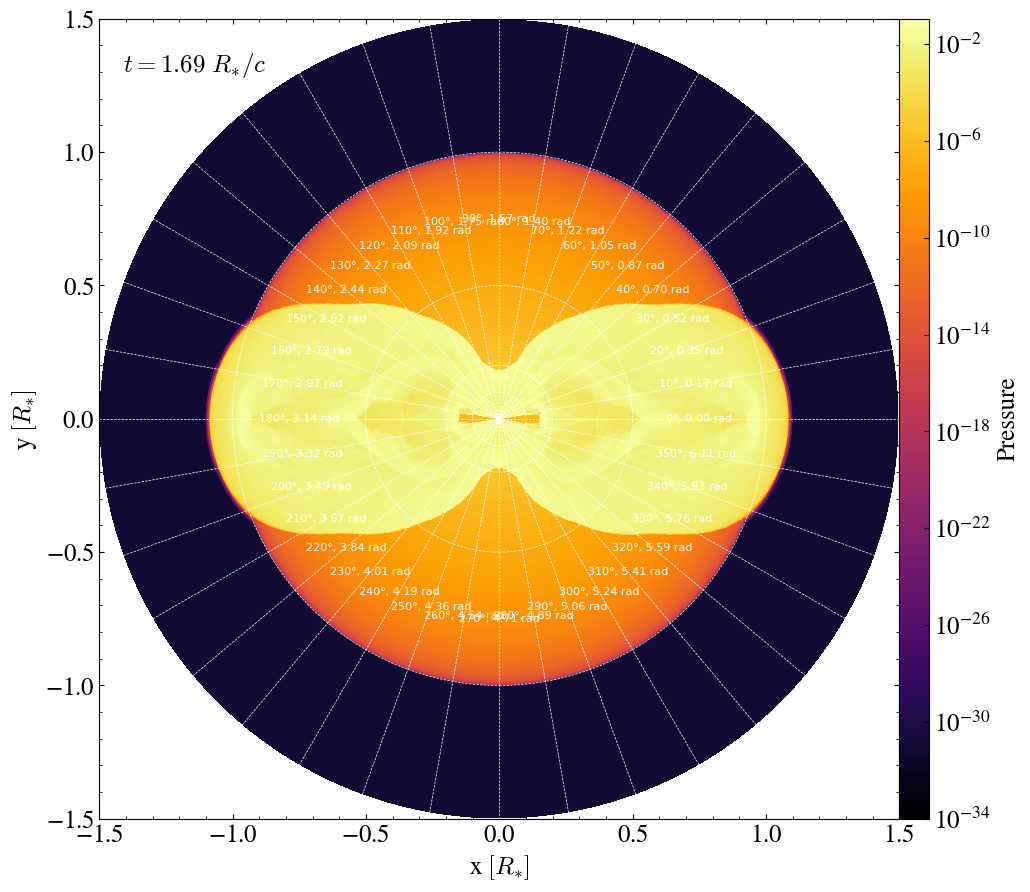

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import yt

ds = yt.load('/scratch/aripoll/athena_out/outputs/jb_exp.out1.01690.athdf')
field = ("gas", "pressure")

p = yt.SlicePlot(ds, "z", field)
p.set_axes_unit("code_length")   # so radii below are in R_*
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"},
                     time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(field, "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(field, r"Pressure")

p.render()   # force yt to build the figure NOW (older yt: p._setup_plots())
ax  = p.plots[field].axes
fig = p.plots[field].figure

for r in [0.10, 0.20, 0.50, 1.0]:
    ax.add_patch(plt.Circle((0, 0), r, color='white', fill=False,
                            linewidth=0.5, linestyle='--'))

r_max = 1.5
for theta_deg in range(0, 360, 10):
    theta = np.radians(theta_deg)
    ax.plot([0, r_max*np.cos(theta)], [0, r_max*np.sin(theta)],
            color='white', linewidth=0.5, linestyle='--')
    ax.text(0.5*r_max*np.cos(theta), 0.5*r_max*np.sin(theta),
            f"{theta_deg}°, {theta:.2f} rad",
            color='white', fontsize=8, ha='center', va='center')

fig

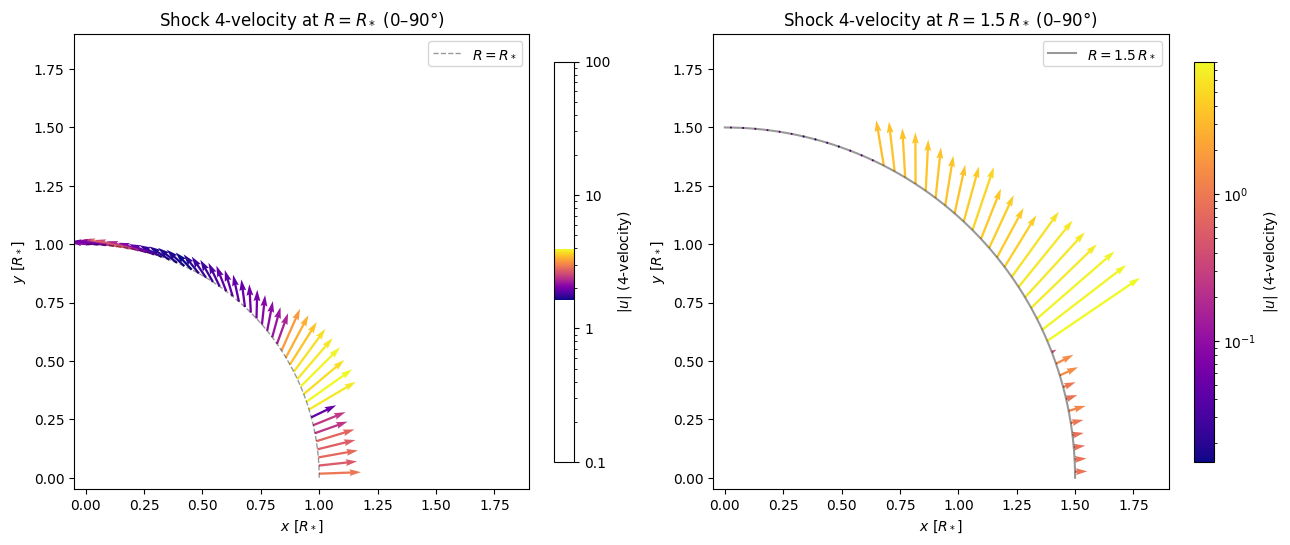

In [17]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

def boundary_arrival_rows(r_tol=0.05, ur_min=0.01):
    """Full shock row (including ur, u_tang) at first R=1.5 boundary arrival per angle.

    ur_min is a threshold on the radial FOUR-velocity, so it is gamma*v_r, not v_r.
    """
    near = (
        fronts[
            (np.abs(fronts['r_shock'] - 1.5) < r_tol) &
            (fronts['ur'] > ur_min)
        ]
        .reset_index()
        .sort_values('time')
    )
    return near.groupby('angle_deg').first().reset_index()

# --- Surface arrival (R=1) ---
arr_surf = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q_surf = arr_surf[(arr_surf['angle_deg'] >= 0) & (arr_surf['angle_deg'] <= 90)].copy()
phi_surf = np.deg2rad(q_surf['angle_deg'].values)
x_surf = np.cos(phi_surf)
y_surf = np.sin(phi_surf)
ur_s  = q_surf['ur'].values
ut_s  = q_surf['u_tang'].values
ux_s  = ur_s * np.cos(phi_surf) - ut_s * np.sin(phi_surf)
uy_s  = ur_s * np.sin(phi_surf) + ut_s * np.cos(phi_surf)
u_s   = np.sqrt(ux_s**2 + uy_s**2)      # = gamma*|v|, not a speed

# --- Boundary arrival (R=1.5) ---
arr = boundary_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
phi_q = np.deg2rad(q['angle_deg'].values)
x_pos = 1.5 * np.cos(phi_q)
y_pos = 1.5 * np.sin(phi_q)
ur  = q['ur'].values
ut  = q['u_tang'].values
ux  = ur * np.cos(phi_q) - ut * np.sin(phi_q)
uy  = ur * np.sin(phi_q) + ut * np.cos(phi_q)
u_b = np.sqrt(ux**2 + uy**2)            # = gamma*|v|, not a speed

# Separate norms so each panel's colorbar reflects its own data range
norm_s = mcolors.LogNorm(vmin=u_s[u_s > 0].min(), vmax=u_s.max())
norm_b = mcolors.LogNorm(vmin=u_b[u_b > 0].min(), vmax=u_b.max())

# Separate arrow scales so both sets are visually legible
arrow_scale_s = 0.12 / u_s.max() if u_s.max() > 0 else 1.0
arrow_scale_b = 0.12 / u_b.max() if u_b.max() > 0 else 1.0

theta_arc = np.linspace(0, np.pi/2, 300)

fig, ax = plt.subplots(1, 2, figsize=(13, 9))
ax[0].plot(np.cos(theta_arc), np.sin(theta_arc),
           'k--', lw=1, alpha=0.4, label=r'$R = R_*$')
ax[1].plot(1.5*np.cos(theta_arc), 1.5*np.sin(theta_arc),
           'k-', lw=1.5, alpha=0.4, label=r'$R = 1.5\,R_*$')

# Surface arrows (R=1)
qv_surf = ax[0].quiver(
    x_surf, y_surf,
    ux_s * arrow_scale_s, uy_s * arrow_scale_s,
    u_s, cmap='plasma', norm=norm_s,
    angles='xy', scale_units='xy', scale=0.5,
    width=0.005
)

# Boundary arrows (R=1.5)
qv_out = ax[1].quiver(
    x_pos, y_pos,
    ux * arrow_scale_b, uy * arrow_scale_b,
    u_b, cmap='plasma', norm=norm_b,
    angles='xy', scale_units='xy', scale=0.25,
    width=0.005
)

cbar_surf = fig.colorbar(qv_surf, ax=ax[0], label=r'$|u| = \gamma v$', fraction=0.04)
cbar_out = fig.colorbar(qv_out, ax=ax[1], label=r'$|u| = \gamma v$', fraction=0.04)

# Force a labeled tick at |u|=1 on the surface colorbar (LogLocator won't
# always land exactly on 1 depending on vmin/vmax).  |u|=1 is gamma=sqrt(2),
# i.e. v=0.707c, NOT the speed of light.
surf_ticks = sorted(set(cbar_surf.get_ticks()) | {1.0})
cbar_surf.set_ticks(surf_ticks)
cbar_surf.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))

ax[0].set_xlim(-0.05, 1.9)
ax[0].set_ylim(-0.05, 1.9)
ax[0].set_aspect('equal')
ax[0].set_xlabel(r'$x\ [R_*]$')
ax[0].set_ylabel(r'$y\ [R_*]$')
ax[0].set_title(r'Shock 4-velocity at $R = R_*$ ($0$–$90°$)')
ax[0].legend(loc='upper right')

ax[1].set_xlim(-0.05, 1.9)
ax[1].set_ylim(-0.05, 1.9)
ax[1].set_aspect('equal')
ax[1].set_xlabel(r'$x\ [R_*]$')
ax[1].set_ylabel(r'$y\ [R_*]$')
ax[1].set_title(r'Shock 4-velocity at $R = 1.5\,R_*$ ($0$–$90°$)')
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Video of the whole thing

In [ ]:
from pathlib import Path
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)

for i, ds in enumerate(ts[800:1100], start=800):
    r_shock_entropy = []  # list of lists: 1 or more radii per theta

    for theta_val in theta_vals:
        ray = ds.ortho_ray(0, (theta_val, z_val))

        df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
        df_entr = df_entr.sort_values('r').reset_index(drop=True)

        if len(df_entr) < 2:
            r_shock_entropy.append([np.nan])
            continue

        # Shock has hit the surface: outer boundary entropy is still unshocked
        if np.log10(df_entr['entropy'].iloc[-1]) < 5:
            r_shock_entropy.append([1.5])
            # print(f"Shock at surface for theta={theta_val:.3f} rad")
            continue

        dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
        abs_grad = np.abs(dlogS_dr)

        peaks, _ = find_peaks(abs_grad, height= 100, distance = 10)
        radii = [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2]

        if radii:
            # print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
            r_shock_entropy.append(radii)
        else:
            r_shock_entropy.append([np.nan])
        # fig, ax = plt.subplots()
        # ax.plot(df_entr['r'], abs_grad, label='Entropy')
        # for r in radii:
        #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
        # ax.set_xlabel(r"$r \ [R_*]$")
        # ax.set_ylabel(r"Entropy $\mathcal{S}$")
        # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds.current_time):.2f}\ R_*/c$") 
        # ax.legend()
        # plt.show()

    # Flatten for polar plot: duplicate theta for entries with two fronts
    plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
    plot_r     = [r  for rs in r_shock_entropy for r in rs]

    plt.figure(figsize=(20, 20))
    plt.polar(plot_theta, plot_r, marker='o', color='g', linestyle='none')
    plt.title(rf"Shock Radius from Entropy Gradient at $t = {float(ds.current_time):.2f}\ R_*/c$")
    plt.savefig(frames_dir / f"frame_{i:04d}.png", dpi=100, bbox_inches='tight')
    plt.close()

In [ ]:
#Now make a video using ffmpeg starting from the first frame frame_1400.png to frame_1499.png
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
import subprocess
subprocess.run(['ffmpeg', '-y', '-framerate', '10', '-start_number', '800', '-i', str(frames_dir / 'frame_%04d.png'), '-c:v', 'libx264', '-pix_fmt', 'yuv420p', '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2', 'shock_evolution.mp4'], check=True)

from IPython.display import Video, display
display(Video('shock_evolution.mp4', embed=True))